# ResNet-20 Activation Comparison Template (CIFAR-100, PyTorch)

A single template that trains a CIFAR-style ResNet-20 with **one of five activation functions**, swappable via a single config knob:

`"relu"` | `"gelu"` | `"silu"` | `"relu2"` | `"swiglu"`

## Held-constant settings (spec)

- **Length**: 200 epochs, 2 seeds `{0, 1}` (override `SEEDS` in Cell 2 for the spec's 3-seed run)
- **Optimizer**: SGD-Nesterov, LR 0.1, momentum 0.9, batch 128
- **LR schedule**: plain cosine annealing to 0 (no warmup)
- **Loss**: `CrossEntropyLoss`, label smoothing = 0.0
- **Weight decay**: 5e-4 applied **only** to conv weights and the FC weight (BN gamma/beta + all biases excluded)
- **Head**: GAP -> Dropout(p=0.1) -> Linear
- **Stochastic Depth (DropPath)**: per-sample mask `(B, 1, 1, 1)`, inverse-scaled at train, identity at eval; linearly depth-scaled `p_i = (i / (L-1)) * p_max` with `p_max = 0.1`, applied only to the residual branch; one DropPath per block, baked at construction
- **BN**: momentum 0.01 (PyTorch convention; equivalent to TF 0.99), eps 1e-5; included in the 1x1 projection shortcut
- **BN recalibration** before final test eval
- **Data**: CIFAR-100, 45k / 5k / 10k split with a single fixed split seed shared across all variants
- **Train aug**: `RandomCrop(32, padding=4)` + `RandomHorizontalFlip(p=0.5)` only (no ColorJitter)
- **Eval checkpoint**: last-epoch (no best-checkpoint tracking)
- **Sparsity metric**: `mean(|y| < 1e-2)` measured at every activation slot (1 stem + 2 x 9 blocks = 19 slots); headline = mean across the 19 layers, plus a per-layer line plot

## Activation handling

The **only** activation-aware code is the slot-1 sublayer factory and the slot-2 fallback:

- **Pointwise** (`relu`, `gelu`, `silu`, `relu2`): slot-1 is `Conv -> BN -> pointwise_act`.
- **Gated** (`swiglu`): slot-1 is `Conv(in -> 2*out) -> BN -> split -> a * SiLU(b)`. Channel doubling is a private implementation detail; the sublayer's external contract `(in, out, stride)` is identical to the pointwise variant.

Everything downstream of slot-1 (Conv2 + BN2, DropPath, shortcut, post-add activation, head, training loop, sparsity hook) is shared.

## AMP

Detected automatically by compute capability:

| Hardware | AMP | dtype | GradScaler |
|---|---|---|---|
| CPU | off | fp32 | no |
| CUDA, sm_80+ (Ampere/Ada/Hopper) | on | bf16 | no (FP32 dynamic range) |
| CUDA, older (Volta/Turing) | on | fp16 | yes |

## Usage

Set `ACTIVATION` in the config cell, then run top-to-bottom. The default flow is now:

- **Cell 17 (driver)**: trains every `(regularizer cell, seed)` combination for the chosen `ACTIVATION` -- 4 cells (`baseline`, `dropout`, `weight_decay`, `stochastic_depth`) x 2 seeds = **8 runs** -- and evaluates each model on CIFAR-100-C inline (10k images per corruption, seeded subset that aligns across activations). All runs are stored in `all_runs`.
- **Cells 19, 21**: produce **one aggregate figure set per regularizer cell**, with mean +/- 95% CI ribbons/bars across the seeded runs. No plot is rendered for individual seeded runs.
  - Cell 19: training curves, per-layer activation sparsity, clean CIFAR-100 endpoint.
  - Cell 21: CIFAR-100-C severity profile, per-category bars, per-corruption bars.
- **Cell 23**: cross-regularizer summary -- bars per regularizer cell with CI for clean top-1 / top-5, CIFAR-100-C top-1, and mean sparsity. ANOVA is intentionally omitted in this revision.

Optional: run the smoke test cell to sanity-check the pipeline quickly, or call `run_full_sweep()` directly if you only want the regularizer grid without the inline CIFAR-100-C eval.

In [17]:
# =====================================================================
# Cell 1 -- Imports (with timing prints to diagnose slow / hanging starts)
# =====================================================================
# Each stage prints its wall-clock cost. If any single line takes >10 s,
# that's the bottleneck. On Windows, the CUDA probe is usually the slow one
# the first time the kernel starts.

import time as _time
_t0 = _time.time(); _last = _t0
def _stage(label):
    global _last
    now = _time.time()
    print(f"  [{now - _t0:6.2f}s | +{now - _last:5.2f}s] {label}", flush=True)
    _last = now

print("Cell 1: starting imports ...", flush=True)

import os
import json
import math
import time
import random
from collections import defaultdict
from contextlib import nullcontext
_stage("stdlib imports done")

import numpy as np
_stage("numpy import done")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
_stage("torch imports done")

import torchvision
import torchvision.transforms as transforms
_stage("torchvision imports done")

from tqdm.auto import tqdm
_stage("tqdm.auto import done")

_cuda_available = torch.cuda.is_available()
_stage(f"torch.cuda.is_available() -> {_cuda_available}")

DEVICE = torch.device("cuda" if _cuda_available else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
    _stage("torch.cuda.get_device_name(0) done")
    cap = torch.cuda.get_device_capability(0)
    _stage("torch.cuda.get_device_capability(0) done")
    print(f"Compute capability: sm_{cap[0]}{cap[1]}")

print(f"Cell 1: total elapsed {_time.time() - _t0:.2f}s", flush=True)

Cell 1: starting imports ...
  [  0.00s | + 0.00s] stdlib imports done
  [  0.00s | + 0.00s] numpy import done
  [  0.00s | + 0.00s] torch imports done
  [  0.00s | + 0.00s] torchvision imports done
  [  0.00s | + 0.00s] tqdm.auto import done
  [  0.00s | + 0.00s] torch.cuda.is_available() -> True
PyTorch: 2.11.0+cu128
Device:  cuda
GPU:     NVIDIA GeForce RTX 3080
  [  0.00s | + 0.00s] torch.cuda.get_device_name(0) done
  [  0.01s | + 0.00s] torch.cuda.get_device_capability(0) done
Compute capability: sm_86
Cell 1: total elapsed 0.01s


In [18]:
# =====================================================================
# Cell 2 -- Configuration (the only thing that changes per variant)
# =====================================================================

# ---- the single swap point ----
ACTIVATION         = "swiglu"        # one of: "relu" | "gelu" | "silu" | "relu2" | "swiglu"

# ---- spec values (do not change for the final study) ----
NUM_CLASSES        = 100
NUM_EPOCHS         = 200           # spec: 200 epochs final
BATCH_SIZE         = 128
INITIAL_LR         = 0.1
MOMENTUM           = 0.9
NESTEROV           = True
WARMUP_EPOCHS      = 0             # spec: plain cosine, no warmup
ETA_MIN            = 0.0
LABEL_SMOOTHING    = 0.0
SEEDS              = (0, 1)        # 2 seeds per (activation, regularizer) -> 4 cells x 2 = 8 runs

# Regularizer values (used when the corresponding "cell" is selected in run_experiment).
DROPOUT_P          = 0.1           # head Dropout between GAP and FC
WEIGHT_DECAY       = 5e-4          # applied only to conv weights + FC weight
DROP_PATH_P_MAX    = 0.1           # linearly scaled across the L=9 residual blocks

# BatchNorm
BN_MOMENTUM        = 0.01          # PyTorch convention (= TF 0.99 effective update rate)
BN_EPS             = 1e-5

# Data
TRAIN_SIZE         = 45_000
VAL_SIZE           = 5_000
SPLIT_SEED         = 12345         # SAME across all activations + all seeds
DATA_ROOT          = "./data"
NUM_WORKERS        = 6         # >0 enables persistent_workers in build_loaders

CIFAR100_MEAN      = (0.5071, 0.4865, 0.4409)
CIFAR100_STD       = (0.2673, 0.2564, 0.2762)

# cuDNN
CUDNN_BENCHMARK     = True
CUDNN_DETERMINISTIC = False

# Safety: gradient clip is ~no-op for ReLU/GELU/SiLU but useful for SwiGLU/ReLU^2.
# Apply uniformly to all activations so the comparison stays fair.
GRAD_CLIP_MAX_NORM = 1.0

# Sparsity metric
SPARSITY_EPS       = 1e-2          # threshold for the |y| < eps fraction
SPARSITY_BATCHES   = 20            # val batches to average over

# Logging / I/O
LOG_EVERY_EPOCH    = False     # True = tqdm.write every epoch, False = every 10 epochs (and final)
RESULTS_DIR        = f"./results_{ACTIVATION}"
os.makedirs(RESULTS_DIR, exist_ok=True)

# CIFAR-100-C evaluation
CIFAR100C_DIR           = os.path.join(DATA_ROOT, "CIFAR-100-C")
CIFAR100C_TAR           = os.path.join(DATA_ROOT, "CIFAR-100-C.tar")
CIFAR100C_INCLUDE_EXTRAS = False   # False = standard 15 corruptions; True = all 19
CIFAR100C_IMAGES_PER_CORR = 10_000 # same count as clean CIFAR-100 test set per corruption
CIFAR100C_SAMPLE_SEED_BASE = 20260508

print(f"ACTIVATION = {ACTIVATION!r}")
print(f"NUM_EPOCHS = {NUM_EPOCHS}, batch = {BATCH_SIZE}, lr = {INITIAL_LR}")
print(f"Seeds      = {SEEDS}")
print(f"Results to {RESULTS_DIR}")

ACTIVATION = 'swiglu'
NUM_EPOCHS = 200, batch = 128, lr = 0.1
Seeds      = (0, 1)
Results to ./results_swiglu


In [3]:
# =====================================================================
# Cell 3 -- AMP detection (capability-aware)
# =====================================================================

def _select_amp():
    """Returns (enabled: bool, dtype: torch.dtype, needs_scaler: bool).

    - CPU                         -> AMP off, fp32, no scaler
    - CUDA, capability >= sm_80   -> bf16 (FP32 dynamic range, no GradScaler needed)
    - CUDA, older (Volta/Turing)  -> fp16 with GradScaler

    bf16 is preferred on Ampere+ because it has the same exponent range as FP32,
    which removes the overflow risk that motivates GradScaler with fp16. fp16 is
    used as a fallback on older cards that lack native bf16 throughput.
    """
    if not torch.cuda.is_available():
        return False, torch.float32, False
    major, _ = torch.cuda.get_device_capability(0)
    if major >= 8:
        return True, torch.bfloat16, False
    return True, torch.float16, True


USE_AMP, AMP_DTYPE, AMP_NEEDS_SCALER = _select_amp()
print(f"AMP: enabled={USE_AMP}, dtype={AMP_DTYPE}, needs_scaler={AMP_NEEDS_SCALER}")


def amp_autocast():
    """Context manager that's a no-op on CPU and the right autocast on CUDA."""
    if not USE_AMP:
        return nullcontext()
    return torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE)

AMP: enabled=True, dtype=torch.bfloat16, needs_scaler=False


In [4]:
# =====================================================================
# Cell 4 -- Reproducibility + cuDNN flags
# =====================================================================

def set_seed(seed: int) -> None:
    """Seed Python, NumPy, and torch (CPU + CUDA)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark     = CUDNN_BENCHMARK
    torch.backends.cudnn.deterministic = CUDNN_DETERMINISTIC


def make_loader_generator(seed: int) -> torch.Generator:
    """Per-run generator for DataLoader shuffling order."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g

In [5]:
# =====================================================================
# Cell 5 -- Data pipeline (CIFAR-100, 45k / 5k / 10k)
# =====================================================================

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# Two copies of the train set: one with augmentation, one without.
# random_split is reseeded to the same SPLIT_SEED both times so the same indices
# are picked, giving a consistent val set across all variants and all seeds.
_full_train_aug  = torchvision.datasets.CIFAR100(root=DATA_ROOT, train=True,  download=True, transform=train_transform)
_full_train_eval = torchvision.datasets.CIFAR100(root=DATA_ROOT, train=True,  download=True, transform=eval_transform)
test_set         = torchvision.datasets.CIFAR100(root=DATA_ROOT, train=False, download=True, transform=eval_transform)

_split_gen = torch.Generator().manual_seed(SPLIT_SEED)
train_set, _ = random_split(_full_train_aug,  [TRAIN_SIZE, VAL_SIZE], generator=_split_gen)
_split_gen = torch.Generator().manual_seed(SPLIT_SEED)
_, val_set   = random_split(_full_train_eval, [TRAIN_SIZE, VAL_SIZE], generator=_split_gen)

print(f"train: {len(train_set)}, val: {len(val_set)}, test: {len(test_set)}")


def build_loaders(seed: int):
    """Build DataLoaders. Reseeds shuffle order via a per-run torch.Generator.

    persistent_workers=True keeps DataLoader workers alive across epochs so
    we don't re-spawn N processes (and re-import torch in each) every epoch.
    Requires num_workers > 0; the flag is gated accordingly.
    """
    g = make_loader_generator(seed)
    persistent = NUM_WORKERS > 0
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              drop_last=False, generator=g,
                              persistent_workers=persistent)
    val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              persistent_workers=persistent)
    test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              persistent_workers=persistent)
    return train_loader, val_loader, test_loader

train: 45000, val: 5000, test: 10000


In [6]:
# =====================================================================
# Cell 6 -- Activation registry + sublayer factory
# =====================================================================
#
# This is the only place in the notebook that "knows" about the difference
# between activations. The block + model + training loop only see sublayers
# satisfying a single contract:
#
#     (in_ch, out_ch, stride) -> nn.Module
#     forward: (B, in_ch, H, W) -> (B, out_ch, H/stride, W/stride)
#
# Pointwise activations get a Conv -> BN -> Act sublayer. SwiGLU gets a
# Conv(in -> 2*out) -> BN -> split -> a * SiLU(b) sublayer. The 2x channel
# doubling is a private implementation detail of the gated path.
# =====================================================================


class ReLUSquared(nn.Module):
    """y = relu(x) ** 2. Same parameter count as ReLU (zero)."""
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(x).square()


def make_pointwise(name: str) -> nn.Module:
    if name == "relu":  return nn.ReLU(inplace=True)
    if name == "gelu":  return nn.GELU()
    if name == "silu":  return nn.SiLU(inplace=True)
    if name == "relu2": return ReLUSquared()
    raise KeyError(f"unknown pointwise activation: {name!r}")


ACTIVATION_REGISTRY = {
    "relu":   {"kind": "pointwise"},
    "gelu":   {"kind": "pointwise"},
    "silu":   {"kind": "pointwise"},
    "relu2":  {"kind": "pointwise"},
    "swiglu": {"kind": "gated"},
}


class PointwiseSubLayer(nn.Module):
    """Conv -> BN -> pointwise activation. Used for ReLU/GELU/SiLU/ReLU^2."""
    def __init__(self, in_ch: int, out_ch: int, stride: int, act_name: str):
        super().__init__()
        self.in_ch, self.out_ch, self.stride = in_ch, out_ch, stride
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch, momentum=BN_MOMENTUM, eps=BN_EPS)
        self.act  = make_pointwise(act_name)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.bn(self.conv(x)))


class SwiGLUSubLayer(nn.Module):
    """Conv(in -> 2*out) -> BN -> split -> a * SiLU(b). Used for SwiGLU.

    The internal conv produces 2*out_ch channels which are split along the
    channel dim into a value half `a` and a gate half `b`. This is the fused
    form of SwiGLU; mathematically identical to the two-projection form used
    in LLaMA / Mistral but uses one matmul instead of two.
    """
    def __init__(self, in_ch: int, out_ch: int, stride: int):
        super().__init__()
        self.in_ch, self.out_ch, self.stride = in_ch, out_ch, stride
        self.conv = nn.Conv2d(in_ch, 2 * out_ch, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(2 * out_ch, momentum=BN_MOMENTUM, eps=BN_EPS)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.bn(self.conv(x))
        a, b = z.chunk(2, dim=1)
        return a * F.silu(b)


def make_slot1(in_ch: int, out_ch: int, stride: int, activation: str) -> nn.Module:
    """Build the slot-1 sublayer for a given activation."""
    if ACTIVATION_REGISTRY[activation]["kind"] == "gated":
        return SwiGLUSubLayer(in_ch, out_ch, stride)
    return PointwiseSubLayer(in_ch, out_ch, stride, activation)


def slot2_act_module(activation: str) -> nn.Module:
    """Post-add (slot 2) activation. Always pointwise.

    SwiGLU degrades to SiLU here because gating slot 2 would require an extra
    conv just to feed the gate, breaking the parameter accounting.
    """
    if activation == "swiglu":
        return nn.SiLU(inplace=True)
    return make_pointwise(activation)

In [7]:
# =====================================================================
# Cell 7 -- DropPath (per-sample stochastic depth)
# =====================================================================

class DropPath(nn.Module):
    """Per-sample stochastic depth on the residual branch.

    During training, each sample independently keeps the residual branch with
    probability `1 - drop_prob` and rescales by `1 / (1 - drop_prob)` so the
    expected output is unchanged. At eval time this is the identity.

    Mask shape is (B, 1, 1, 1) so it broadcasts across channels and spatial dims.
    """
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        assert 0.0 <= drop_prob < 1.0, drop_prob
        self.drop_prob = float(drop_prob)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = x.new_empty(shape).bernoulli_(keep)
        return x * (mask / keep)

    def extra_repr(self) -> str:
        return f"drop_prob={self.drop_prob}"

In [8]:
# =====================================================================
# Cell 8 -- Unified BasicBlock + ResNet-20
# =====================================================================
#
# Block layout (post-activation):
#
#     slot1(in -> c_mid) -> Conv2(c_mid -> planes) -> BN2 -> DropPath
#         -> + shortcut(x) -> slot2_act
#
# c_mid = planes // 2 for SwiGLU (param-balanced gated width); else planes.
# Slot-1 sublayer comes from the factory; everything downstream is shared.
# =====================================================================


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes: int, planes: int, stride: int,
                 drop_path_p: float, activation: str):
        super().__init__()
        is_gated = ACTIVATION_REGISTRY[activation]["kind"] == "gated"
        c_mid = planes // 2 if is_gated else planes

        self.activation = activation
        self.is_gated   = is_gated
        self.c_mid      = c_mid

        # Slot 1: factory-provided sublayer satisfying the (in, out, stride) contract.
        self.slot1 = make_slot1(in_planes, c_mid, stride, activation)

        # Conv2 + BN2 are unactivated here; the activation lives after the residual add.
        self.conv2 = nn.Conv2d(c_mid, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes, momentum=BN_MOMENTUM, eps=BN_EPS)

        self.drop_path = DropPath(drop_path_p)

        # Projection shortcut whenever shape changes (stride > 1 or channel mismatch).
        # BN is included in the shortcut per spec.
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(planes, momentum=BN_MOMENTUM, eps=BN_EPS),
            )
        else:
            self.shortcut = nn.Identity()

        # Slot 2: pointwise activation after the residual add.
        self.slot2_act = slot2_act_module(activation)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.slot1(x)
        out = self.bn2(self.conv2(out))
        out = self.drop_path(out)
        out = out + self.shortcut(x)
        return self.slot2_act(out)


class ResNet20(nn.Module):
    """CIFAR-style ResNet-20 with swappable activation.

        Stem  : slot1(3 -> 16, stride 1)                  # absorbs first activation
        Stage1: 3 BasicBlock at planes=16
        Stage2: 3 BasicBlock at planes=32 (first block strides 2 + 1x1 projection)
        Stage3: 3 BasicBlock at planes=64 (first block strides 2 + 1x1 projection)
        Head  : GAP -> Dropout(p) -> Linear(64 -> num_classes)
    """
    NUM_BLOCKS_PER_STAGE = (3, 3, 3)
    STAGE_PLANES         = (16, 32, 64)

    def __init__(self,
                 activation: str,
                 num_classes: int = NUM_CLASSES,
                 dropout_p: float = DROPOUT_P,
                 drop_path_p_max: float = DROP_PATH_P_MAX):
        super().__init__()
        assert activation in ACTIVATION_REGISTRY, f"unknown activation: {activation!r}"
        self.activation       = activation
        self.num_classes      = num_classes
        self.dropout_p        = dropout_p
        self.drop_path_p_max  = drop_path_p_max

        # Stem: slot-1 sublayer producing 16 channels.
        self.stem = make_slot1(3, self.STAGE_PLANES[0], stride=1, activation=activation)

        # Linearly-scaled stochastic depth across the L=9 residual blocks:
        #   p_i = (i / (L - 1)) * p_max     for i in [0, L-1].
        # One DropPath per block, baked at construction.
        L = sum(self.NUM_BLOCKS_PER_STAGE)
        if L > 1 and drop_path_p_max > 0.0:
            dp_rates = [(i / (L - 1)) * drop_path_p_max for i in range(L)]
        else:
            dp_rates = [0.0] * L

        self.stages = nn.ModuleList()
        in_planes = self.STAGE_PLANES[0]
        block_idx = 0
        for s_idx, planes in enumerate(self.STAGE_PLANES):
            stage_first_stride = 1 if s_idx == 0 else 2
            blocks = []
            for b_idx in range(self.NUM_BLOCKS_PER_STAGE[s_idx]):
                stride = stage_first_stride if b_idx == 0 else 1
                blocks.append(BasicBlock(
                    in_planes=in_planes,
                    planes=planes,
                    stride=stride,
                    drop_path_p=dp_rates[block_idx],
                    activation=activation,
                ))
                in_planes = planes
                block_idx += 1
            self.stages.append(nn.Sequential(*blocks))

        # Head: GAP -> Dropout(p) -> Linear.
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_p) if dropout_p > 0.0 else nn.Identity()
        self.fc      = nn.Linear(self.STAGE_PLANES[-1], num_classes, bias=True)

        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

In [9]:
# =====================================================================
# Cell 9 -- Weight-decay parameter groups + plain cosine LR
# =====================================================================

def build_param_groups(model: nn.Module, weight_decay: float):
    """Apply WD to conv weights and the Linear-head weight only.
    Exclude all BN gamma/beta and all biases."""
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.endswith(".bias"):
            no_decay.append(p)
            continue
        # BatchNorm weight (gamma) is 1-D, exclude it; conv/linear weights are 2-D+.
        if p.ndim == 1:
            no_decay.append(p)
            continue
        decay.append(p)
    return [
        {"params": decay,    "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]


class CosineLR:
    """Plain cosine annealing from `base_lr` to `eta_min` over `total_epochs`. No warmup.

    `epoch` is the (possibly fractional) current epoch index. We step once per
    epoch, which matches the spec's logging granularity.
    """
    def __init__(self, optimizer, base_lr: float, total_epochs: int, eta_min: float = 0.0):
        self.optimizer    = optimizer
        self.base_lr      = base_lr
        self.total_epochs = total_epochs
        self.eta_min      = eta_min

    def lr_at(self, epoch: float) -> float:
        progress = min(max(epoch / max(1, self.total_epochs - 1), 0.0), 1.0)
        return self.eta_min + 0.5 * (self.base_lr - self.eta_min) * (1.0 + math.cos(math.pi * progress))

    def step(self, epoch: float) -> float:
        lr = self.lr_at(epoch)
        for pg in self.optimizer.param_groups:
            pg["lr"] = lr
        return lr

In [10]:
# =====================================================================
# Cell 10 -- Train / eval / BN recalibration (with AMP)
# =====================================================================

def _accuracy_top_k(logits: torch.Tensor, targets: torch.Tensor, k: int = 1) -> float:
    with torch.no_grad():
        _, pred = logits.topk(k, dim=1, largest=True, sorted=True)
        correct = pred.eq(targets.view(-1, 1).expand_as(pred)).any(dim=1)
        return correct.float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, scaler, *, desc: str = "train"):
    """Train one epoch with NaN/inf-safe optimizer steps and optional GradScaler.

    Safety (uniform across all activations):
      1. If forward loss is NaN/inf, skip the optimizer step.
      2. After backward + grad-clip, if any gradient is NaN/inf, skip the step.

    Both are rare for ReLU/GELU/SiLU, but useful for SwiGLU's volatile gradients
    and for ReLU^2's occasional early-training spikes. Skipped batches still
    contribute to the accuracy average; their loss is excluded from the mean.

    Pass `desc=None` to suppress the per-batch tqdm bar.
    """
    model.train()
    n_samples, top1_sum = 0, 0.0
    loss_sum, n_loss = 0.0, 0
    n_skipped = 0

    iterator = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True) if desc else loader
    for x, y in iterator:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp_autocast():
            logits = model(x)
            loss   = criterion(logits, y)

        bs = x.size(0)
        n_samples += bs
        top1_sum  += _accuracy_top_k(logits, y, 1) * bs

        if not torch.isfinite(loss):
            n_skipped += 1
            continue

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if GRAD_CLIP_MAX_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_MAX_NORM)
            bad_grad = any(
                (p.grad is not None) and (not torch.isfinite(p.grad).all())
                for p in model.parameters()
            )
            if bad_grad:
                n_skipped += 1
                optimizer.zero_grad(set_to_none=True)
                scaler.update()
                continue
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if GRAD_CLIP_MAX_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_MAX_NORM)
            bad_grad = any(
                (p.grad is not None) and (not torch.isfinite(p.grad).all())
                for p in model.parameters()
            )
            if bad_grad:
                n_skipped += 1
                optimizer.zero_grad(set_to_none=True)
                continue
            optimizer.step()

        loss_sum += loss.item() * bs
        n_loss   += bs

        if desc and n_loss > 0:
            iterator.set_postfix(loss=f"{loss_sum/n_loss:.3f}",
                                 top1=f"{100*top1_sum/n_samples:.2f}",
                                 skip=n_skipped)

    avg_loss = (loss_sum / n_loss) if n_loss > 0 else float("nan")
    if n_skipped > 0:
        tqdm.write(f"    [train] skipped {n_skipped} step(s) due to NaN/inf loss or gradients")
    return avg_loss, top1_sum / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, *, desc: str = "eval"):
    """Run forward-only evaluation. Pass `desc=None` to suppress the tqdm bar
    (useful when the caller already shows higher-level progress, e.g. inside
    `evaluate_cifar100c`)."""
    model.eval()
    n_samples, loss_sum, top1_sum, top5_sum = 0, 0.0, 0.0, 0.0
    iterator = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True) if desc else loader
    for x, y in iterator:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with amp_autocast():
            logits = model(x)
            loss   = criterion(logits, y)

        bs = x.size(0)
        n_samples += bs
        loss_sum  += loss.item() * bs
        top1_sum  += _accuracy_top_k(logits, y, 1) * bs
        top5_sum  += _accuracy_top_k(logits, y, 5) * bs

        if desc:
            iterator.set_postfix(loss=f"{loss_sum/n_samples:.3f}",
                                 top1=f"{100*top1_sum/n_samples:.2f}")

    return {
        "loss": loss_sum / n_samples,
        "top1": top1_sum / n_samples,
        "top5": top5_sum / n_samples,
    }


@torch.no_grad()
def recalibrate_bn_stats(model, loader, max_batches=None, *, desc: str = "bn-recal") -> int:
    """Reset and re-estimate BN running mean/var from a clean forward-only pass.

    Spec: BN recalibration before final test eval. Run this once after training,
    before the final test pass. Adds ~one epoch of forward time per run.

    Implementation notes (the WD recalibration fix):
      1. bn.momentum is temporarily set to None for the recal pass. PyTorch
         interprets momentum=None as a cumulative moving average (equal weight
         to every batch since reset). Using the trained momentum=BN_MOMENTUM=0.01
         here biases recal stats toward the reset value (var=1.0) by
         (1 - 0.01)^n_batches ~ 3% over a single epoch, which is catastrophic
         for layers whose true running variance is much smaller than 1.0
         (notably weight-decay-trained networks). Original momentum is
         restored after the pass so subsequent .train() calls preserve the
         spec'd training-time BN behavior.
      2. The model is kept in eval() mode and only BN modules are toggled
         to train() individually. This ensures Dropout / DropPath are
         deactivated during recal (deterministic block contributions),
         which matters for the stochastic_depth regularizer cell.

    Pass `desc=None` to suppress the per-batch tqdm bar.
    """
    saved_momenta = {}
    model.eval()
    for name, m in model.named_modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            saved_momenta[name] = m.momentum
            m.momentum = None
            m.reset_running_stats()
            m.train()

    n_batches = 0
    total = max_batches if max_batches is not None else len(loader)
    iterator = (tqdm(loader, desc=desc, total=total, leave=False, dynamic_ncols=True)
                if desc else loader)
    for i, (x, _) in enumerate(iterator):
        if max_batches is not None and i >= max_batches:
            break
        x = x.to(DEVICE, non_blocking=True)
        with amp_autocast():
            _ = model(x)
        n_batches += 1

    for name, m in model.named_modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.momentum = saved_momenta[name]
    model.eval()
    return n_batches

In [11]:
# =====================================================================
# Cell 11 -- Sparsity hook + per-layer plot
# =====================================================================
#
# Spec metric: at every activation slot (1 stem + 2 * 9 blocks = 19 slots),
# compute mean(|y| < eps) per layer with eps = 1e-2. Headline = mean across
# the 19 layers.
#
# For pointwise activations the slot output is the .act / slot2_act module's
# output. For SwiGLU there is no separate .act submodule (the gating happens
# inside SwiGLUSubLayer.forward), so we hook the sublayer itself.
# =====================================================================


def _slot_modules(model: ResNet20):
    """Return [(name, module), ...] for the 19 activation slots in forward order."""
    is_gated = ACTIVATION_REGISTRY[model.activation]["kind"] == "gated"
    slots = []
    if is_gated:
        slots.append(("stem", model.stem))
    else:
        slots.append(("stem.act", model.stem.act))
    for s_idx, stage in enumerate(model.stages):
        for b_idx, block in enumerate(stage):
            tag = f"stage{s_idx+1}.blk{b_idx+1}"
            if is_gated:
                slots.append((f"{tag}.slot1", block.slot1))
            else:
                slots.append((f"{tag}.slot1.act", block.slot1.act))
            slots.append((f"{tag}.slot2_act", block.slot2_act))
    return slots


@torch.no_grad()
def measure_sparsity(model: ResNet20, loader,
                     eps: float = SPARSITY_EPS,
                     max_batches: int = SPARSITY_BATCHES,
                     *,
                     desc: str = "sparsity") -> dict:
    """Mean fraction of activation outputs with |y| < eps, per slot, over `max_batches`.

    Pass `desc=None` to suppress the per-batch tqdm bar.
    """
    model.eval()
    slots = _slot_modules(model)
    sums   = {name: 0.0 for name, _ in slots}
    counts = {name: 0   for name, _ in slots}

    hooks = []
    for name, mod in slots:
        def make_hook(n):
            def hook(_m, _in, out):
                sums[n]   += (out.abs() < eps).float().mean().item()
                counts[n] += 1
            return hook
        hooks.append(mod.register_forward_hook(make_hook(name)))

    iterator = (tqdm(loader, desc=desc, total=max_batches, leave=False, dynamic_ncols=True)
                if desc else loader)
    for i, (x, _) in enumerate(iterator):
        if i >= max_batches:
            break
        x = x.to(DEVICE, non_blocking=True)
        with amp_autocast():
            _ = model(x)

    for h in hooks:
        h.remove()

    per_layer = {n: (sums[n] / max(counts[n], 1)) for n, _ in slots}
    headline  = float(np.mean(list(per_layer.values())))
    return {
        "_layer_order":  [n for n, _ in slots],
        "_eps":          eps,
        "headline_mean": headline,
        "per_layer":     per_layer,
    }


def plot_sparsity(sparsity: dict, title: str = None, ax=None):
    """Per-layer sparsity line plot. The depth profile of |y| < eps."""
    import matplotlib.pyplot as plt
    order = sparsity["_layer_order"]
    vals  = [sparsity["per_layer"][n] for n in order]
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4))
    ax.plot(range(len(order)), vals, marker="o")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=60, ha="right", fontsize=8)
    ax.axhline(sparsity["headline_mean"], ls="--", alpha=0.5,
               label=f"mean across layers = {sparsity['headline_mean']:.3f}")
    ax.set_ylabel(f"frac(|y| < {sparsity['_eps']})")
    ax.set_ylim(0, 1)
    ax.set_title(title or "Per-layer activation sparsity")
    ax.legend()
    return ax

In [12]:
# =====================================================================
# Cell 12 -- run_experiment(): one full (activation, cell, knob, seed) run
# =====================================================================

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def run_experiment(*,
                   activation: str = None,
                   cell: str = "baseline",
                   knob: float = 0.0,
                   seed: int = 0,
                   num_epochs: int = NUM_EPOCHS,
                   verbose: bool = True,
                   return_model: bool = False) -> dict:
    """Train one configuration end-to-end. Last-epoch checkpoint per spec.

    Args:
        activation : one of ACTIVATION_REGISTRY keys. Defaults to ACTIVATION.
        cell       : "baseline" | "dropout" | "weight_decay" | "stochastic_depth".
        knob       : the regularizer's hyperparameter value (ignored for baseline).
        seed       : random seed (controls model init + dataloader shuffle order).
        num_epochs : training epochs (defaults to NUM_EPOCHS = 200).
        verbose    : print per-epoch logs.
        return_model : if True, include the trained model object under key "model".

    Returns: dict of run metadata + per-epoch history + sparsity + final test metrics.
    """
    if activation is None:
        activation = ACTIVATION
    assert activation in ACTIVATION_REGISTRY, f"unknown activation: {activation!r}"
    assert cell in {"baseline", "dropout", "weight_decay", "stochastic_depth"}, cell

    # Knob -> regularizer mapping. Baseline has all regs off.
    dropout_p, weight_decay, drop_path_p_max = 0.0, 0.0, 0.0
    if cell == "dropout":
        dropout_p = float(knob)
    elif cell == "weight_decay":
        weight_decay = float(knob)
    elif cell == "stochastic_depth":
        drop_path_p_max = float(knob)

    set_seed(seed)
    train_loader, val_loader, test_loader = build_loaders(seed)

    model = ResNet20(
        activation=activation,
        num_classes=NUM_CLASSES,
        dropout_p=dropout_p,
        drop_path_p_max=drop_path_p_max,
    ).to(DEVICE)
    n_params = count_parameters(model)

    optimizer = optim.SGD(build_param_groups(model, weight_decay),
                          lr=INITIAL_LR, momentum=MOMENTUM, nesterov=NESTEROV)
    scheduler = CosineLR(optimizer, base_lr=INITIAL_LR,
                         total_epochs=num_epochs, eta_min=ETA_MIN)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, reduction="mean")
    scaler    = torch.amp.GradScaler("cuda") if AMP_NEEDS_SCALER else None

    history = {"epoch": [], "lr": [],
               "train_loss": [], "train_top1": [],
               "val_loss":   [], "val_top1": [], "val_top5": [],
               "epoch_time_s": []}

    run_tag = f"{activation}/{cell}/knob={knob}/seed={seed}"
    if verbose:
        print(f"[{run_tag}] params={n_params:,} | "
              f"dropout={dropout_p}, wd={weight_decay}, sd_max={drop_path_p_max}")

    epoch_pbar = tqdm(range(num_epochs),
                      desc=f"epochs [{run_tag}]",
                      leave=True, dynamic_ncols=True) if verbose else range(num_epochs)
    for epoch in epoch_pbar:
        t0 = time.time()
        lr = scheduler.step(epoch)
        tr_loss, tr_top1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler,
                                           desc=None)
        val_metrics      = evaluate(model, val_loader, criterion,
                                    desc=None)
        elapsed          = time.time() - t0

        history["epoch"].append(epoch)
        history["lr"].append(lr)
        history["train_loss"].append(tr_loss)
        history["train_top1"].append(tr_top1)
        history["val_loss"].append(val_metrics["loss"])
        history["val_top1"].append(val_metrics["top1"])
        history["val_top5"].append(val_metrics["top5"])
        history["epoch_time_s"].append(elapsed)

        if verbose:
            epoch_pbar.set_postfix(lr=f"{lr:.4f}",
                                   tr_top1=f"{tr_top1*100:.2f}",
                                   val_top1=f"{val_metrics['top1']*100:.2f}",
                                   sec=f"{elapsed:.1f}")

        if verbose and (LOG_EVERY_EPOCH or (epoch + 1) % 10 == 0 or epoch == num_epochs - 1):
            tqdm.write(f"  ep {epoch+1:3d}/{num_epochs} | lr {lr:.4f} | "
                       f"train {tr_loss:.3f}/{tr_top1*100:5.2f}% | "
                       f"val {val_metrics['loss']:.3f}/{val_metrics['top1']*100:5.2f}% "
                       f"| {elapsed:5.1f}s")

    # Spec: last-epoch checkpoint. No best-checkpoint restore. We DO recalibrate
    # BN running stats before the final test eval (also per spec).
    n_recal = recalibrate_bn_stats(model, train_loader,
                                   desc=None)
    if verbose:
        tqdm.write(f"  BN STATS recalibrated from {n_recal} train batches")

    test_metrics = evaluate(model, test_loader, criterion,
                            desc=None)
    if verbose:
        tqdm.write(f"  TEST | loss {test_metrics['loss']:.4f} | "
                   f"top1 {test_metrics['top1']*100:5.2f}% | "
                   f"top5 {test_metrics['top5']*100:5.2f}%")

    sparsity = measure_sparsity(model, val_loader,
                                eps=SPARSITY_EPS, max_batches=SPARSITY_BATCHES,
                                desc=None)
    if verbose:
        tqdm.write(f"  SPARSITY | mean across {len(sparsity['per_layer'])} slots: "
                   f"{sparsity['headline_mean']*100:5.2f}% of outputs "
                   f"|y| < {sparsity['_eps']}")

    out = {
        "activation":      activation,
        "cell":            cell,
        "knob":            knob,
        "seed":            seed,
        "num_epochs":      num_epochs,
        "n_params":        n_params,
        "dropout_p":       dropout_p,
        "weight_decay":    weight_decay,
        "drop_path_p_max": drop_path_p_max,
        "history":         history,
        "test":            test_metrics,
        "sparsity":        sparsity,
    }
    if return_model:
        out["model"] = model
    return out

In [13]:
# =====================================================================
# Cell 13 -- Sanity check: param count, forward shape, slot order
# =====================================================================

_demo = ResNet20(activation=ACTIVATION, num_classes=NUM_CLASSES,
                 dropout_p=0.0, drop_path_p_max=0.0)
_n = count_parameters(_demo)
print(f"{ACTIVATION!r} ResNet-20 trainable parameters: {_n:,}")
print(f"  Pointwise reference (ReLU/GELU/SiLU/ReLU^2): ~278,324 (identical for all four)")
print(f"  Difference from pointwise: {_n - 278_324:+,} ({(_n - 278_324)/278_324*100:+.2f}%)")

_x = torch.randn(2, 3, 32, 32)
with torch.no_grad():
    _y = _demo(_x)
print(f"  Forward shape check: input {tuple(_x.shape)} -> output {tuple(_y.shape)}")

print("\nPer-block channel layout (in -> c_mid -> out):")
print(f"  stem      : 3 -> {_demo.stem.out_ch} -> {_demo.stem.out_ch}")
for s_idx, stage in enumerate(_demo.stages):
    for b_idx, blk in enumerate(stage):
        s1 = blk.slot1
        in_ch  = s1.in_ch
        c_mid  = blk.c_mid
        out_ch = blk.conv2.out_channels
        stride = s1.stride
        print(f"  stage{s_idx+1} blk{b_idx+1}: "
              f"{in_ch:>2} -> {c_mid:>2} -> {out_ch:>2} "
              f"(stride={stride}, drop_path={blk.drop_path.drop_prob:.3f})")

print(f"\nSparsity slot order ({len(_slot_modules(_demo))} slots = 1 stem + 2 * 9 blocks):")
for i, (name, _) in enumerate(_slot_modules(_demo)):
    print(f"  {i:2d}. {name}")

del _demo, _x, _y

'swiglu' ResNet-20 trainable parameters: 206,212
  Pointwise reference (ReLU/GELU/SiLU/ReLU^2): ~278,324 (identical for all four)
  Difference from pointwise: -72,112 (-25.91%)
  Forward shape check: input (2, 3, 32, 32) -> output (2, 100)

Per-block channel layout (in -> c_mid -> out):
  stem      : 3 -> 16 -> 16
  stage1 blk1: 16 ->  8 -> 16 (stride=1, drop_path=0.000)
  stage1 blk2: 16 ->  8 -> 16 (stride=1, drop_path=0.000)
  stage1 blk3: 16 ->  8 -> 16 (stride=1, drop_path=0.000)
  stage2 blk1: 16 -> 16 -> 32 (stride=2, drop_path=0.000)
  stage2 blk2: 32 -> 16 -> 32 (stride=1, drop_path=0.000)
  stage2 blk3: 32 -> 16 -> 32 (stride=1, drop_path=0.000)
  stage3 blk1: 32 -> 32 -> 64 (stride=2, drop_path=0.000)
  stage3 blk2: 64 -> 32 -> 64 (stride=1, drop_path=0.000)
  stage3 blk3: 64 -> 32 -> 64 (stride=1, drop_path=0.000)

Sparsity slot order (19 slots = 1 stem + 2 * 9 blocks):
   0. stem
   1. stage1.blk1.slot1
   2. stage1.blk1.slot2_act
   3. stage1.blk2.slot1
   4. stage1.blk2.

In [14]:
# =====================================================================
# Cell 14 -- Smoke test: 2-epoch run to verify the pipeline trains
#
# This is NOT a real training run -- it just exercises every code path
# (dataloader, model, optimizer, AMP, scheduler, eval, BN recalibration,
# sparsity hook) so you catch bugs without spending hours on a failed config.
# =====================================================================

_smoke = run_experiment(
    activation=ACTIVATION,
    cell="baseline",
    knob=0.0,
    seed=0,
    num_epochs=2,
    verbose=True,
)
print("Smoke test complete.")

[swiglu/baseline/knob=0.0/seed=0] params=206,212 | dropout=0.0, wd=0.0, sd_max=0.0


epochs [swiglu/baseline/knob=0.0/seed=0]:   0%|          | 0/2 [00:00<?, ?it/s]

  ep   2/2 | lr 0.0000 | train 4.456/ 3.00% | val 4.475/ 2.58% |   9.2s
  BN STATS recalibrated from 352 train batches
  TEST | loss 4.4518 | top1  3.15% | top5 12.27%
  SPARSITY | mean across 19 slots:  9.70% of outputs |y| < 0.01
Smoke test complete.


## Sweep driver

The cell below runs the full 4-cell x 3-seed grid for the chosen `ACTIVATION`. Each run is saved as a JSON file under `RESULTS_DIR`. To run for all five activations, either:

1. Manually change `ACTIVATION` in cell 2 and re-run cells 2 + 15 for each one, **or**
2. Wrap this cell in an outer loop that sets `ACTIVATION` and re-imports / re-instantiates as needed (separate notebook copies are cleaner if you want to isolate logs).

The sweep grid below uses the spec headline values: `dropout=0.1`, `weight_decay=5e-4`, `stochastic_depth=0.1`.

In [15]:
# =====================================================================
# Cell 16 -- Full sweep driver (4 cells x len(SEEDS) runs per activation)
# =====================================================================
#
# Each run takes ~30-90 minutes at 200 epochs depending on hardware. The full
# sweep is therefore ~6-18 hours per activation. Comment out and call
# run_experiment() directly for one-off runs.
# =====================================================================

SWEEP_GRID = [
    ("baseline",         0.0),
    ("dropout",          DROPOUT_P),
    ("weight_decay",     WEIGHT_DECAY),
    ("stochastic_depth", DROP_PATH_P_MAX),
]


def run_full_sweep(activation: str = None,
                   seeds=SEEDS,
                   num_epochs: int = NUM_EPOCHS,
                   results_dir: str = None) -> list:
    """Run all (cell, knob) x seeds for a single activation. Saves one JSON per run."""
    if activation is None:
        activation = ACTIVATION
    out_dir = results_dir or f"./results_{activation}"
    os.makedirs(out_dir, exist_ok=True)

    results = []
    pairs = [(c, k, s) for (c, k) in SWEEP_GRID for s in seeds]
    sweep_pbar = tqdm(pairs, desc=f"{activation} sweep", leave=True, dynamic_ncols=True)
    for cell, knob, seed in sweep_pbar:
        sweep_pbar.set_postfix(cell=cell, knob=knob, seed=seed)
        t0 = time.time()
        tqdm.write(f"\n=== {activation} | {cell} | knob={knob} | seed={seed} ===")
        r = run_experiment(activation=activation, cell=cell,
                           knob=knob, seed=seed, num_epochs=num_epochs)
        r["wall_clock_s"] = time.time() - t0
        results.append(r)
        tag = f"{activation}_{cell}_knob{knob}_seed{seed}"
        with open(os.path.join(out_dir, f"{tag}.json"), "w") as f:
            json.dump(r, f, indent=2)
        tqdm.write(f"  --> wall-clock: {r['wall_clock_s']/60:.1f} min")
    return results


# Uncomment to actually launch the sweep:
# results = run_full_sweep()

In [19]:
# =====================================================================
# Cell 17 -- Full-factorial seeded driver across regularizer cells
# =====================================================================
#
# For the chosen ACTIVATION, trains every (regularizer cell, seed) combination
# and evaluates each trained model on CIFAR-100-C with seeded subset sampling.
# Downstream cells then produce ONE aggregate plot per regularizer cell with
# 95% CI ribbons/bars across the seeded runs (no ANOVA).
#
# This cell defines the CIFAR-100-C eval helpers up-front so the driver loop
# can call them inline.
# =====================================================================

import tarfile
import urllib.request
import zlib

CIFAR100C_CORRUPTIONS_BASE = [
    "gaussian_noise", "shot_noise", "impulse_noise",
    "defocus_blur", "glass_blur", "motion_blur", "zoom_blur",
    "snow", "frost", "fog", "brightness",
    "contrast", "elastic_transform", "pixelate", "jpeg_compression",
]
CIFAR100C_CORRUPTIONS_EXTRA = ["speckle_noise", "gaussian_blur", "spatter", "saturate"]

CIFAR100C_CATEGORY = {
    "gaussian_noise": "noise", "shot_noise": "noise", "impulse_noise": "noise", "speckle_noise": "noise",
    "defocus_blur": "blur", "glass_blur": "blur", "motion_blur": "blur", "zoom_blur": "blur", "gaussian_blur": "blur",
    "snow": "weather", "frost": "weather", "fog": "weather", "brightness": "weather", "spatter": "weather",
    "contrast": "digital", "elastic_transform": "digital", "pixelate": "digital", "jpeg_compression": "digital", "saturate": "digital",
}


def get_cifar100c_corruptions(include_extras: bool = CIFAR100C_INCLUDE_EXTRAS):
    if include_extras:
        return CIFAR100C_CORRUPTIONS_BASE + CIFAR100C_CORRUPTIONS_EXTRA
    return list(CIFAR100C_CORRUPTIONS_BASE)


def ensure_cifar100c(data_root: str = DATA_ROOT,
                     target_dir: str = CIFAR100C_DIR,
                     tar_path: str = CIFAR100C_TAR) -> str:
    """Download + extract CIFAR-100-C once (if missing)."""
    labels_path = os.path.join(target_dir, "labels.npy")
    if os.path.exists(labels_path):
        return target_dir
    os.makedirs(data_root, exist_ok=True)
    if not os.path.exists(tar_path):
        url = "https://zenodo.org/record/3555552/files/CIFAR-100-C.tar?download=1"
        print(f"Downloading CIFAR-100-C from {url}")
        urllib.request.urlretrieve(url, tar_path)
    print(f"Extracting {tar_path} to {data_root} ...")
    with tarfile.open(tar_path, "r") as tf:
        tf.extractall(path=data_root)
    if not os.path.exists(labels_path):
        raise FileNotFoundError(f"Expected {labels_path} after extraction")
    return target_dir


def _corruption_seed(corruption: str, severity: int, eval_run_id: int) -> int:
    """Deterministic seed so same eval_run_id aligns image picks across activations."""
    corr_hash = zlib.crc32(corruption.encode("utf-8")) & 0xFFFFFFFF
    return int(CIFAR100C_SAMPLE_SEED_BASE + eval_run_id * 1_000_000 + severity * 10_000 + corr_hash)


def _sample_indices_per_severity(total_per_corr: int, severities) -> dict:
    n_sev = len(severities)
    base = total_per_corr // n_sev
    rem = total_per_corr % n_sev
    return {sev: base + (1 if i < rem else 0) for i, sev in enumerate(severities)}


class CIFAR100CSliceDataset(torch.utils.data.Dataset):
    def __init__(self, images_np, labels_np, selected_idx, mean, std):
        self.images = images_np
        self.labels = labels_np
        self.sel = selected_idx.astype(np.int64)
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std  = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)

    def __len__(self):
        return int(self.sel.shape[0])

    def __getitem__(self, i):
        idx = int(self.sel[i])
        x = torch.from_numpy(self.images[idx]).permute(2, 0, 1).float().div_(255.0)
        x = (x - self.mean) / self.std
        return x, int(self.labels[idx])


@torch.no_grad()
def evaluate_cifar100c(model: nn.Module,
                       eval_run_id: int,
                       severities=(1, 2, 3, 4, 5),
                       include_extras: bool = CIFAR100C_INCLUDE_EXTRAS,
                       images_per_corruption: int = CIFAR100C_IMAGES_PER_CORR,
                       batch_size: int = BATCH_SIZE,
                       num_workers: int = 0,
                       verbose: bool = False) -> dict:
    """Evaluate model on CIFAR-100-C using seeded subset sampling.

    - Uses exactly `images_per_corruption` per corruption (default 10,000).
    - Splits that budget evenly across severities.
    - Same `eval_run_id` aligns image picks across activations.

    num_workers defaults to 0: each (corruption, severity) pair builds a fresh
    DataLoader over a small subset (1-10 batches), so worker spawn cost on
    Windows dwarfs the actual eval work and leaks per-cycle working set.
    """
    root = ensure_cifar100c()
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="mean")
    corruptions = get_cifar100c_corruptions(include_extras)
    sev_budget = _sample_indices_per_severity(images_per_corruption, severities)

    labels_path = os.path.join(root, "labels.npy")
    labels_all = np.load(labels_path)

    per_corruption = {}
    flat_top1 = []

    pair_total = len(corruptions) * len(severities)
    pbar = tqdm(total=pair_total, desc="C-100-C", leave=False, dynamic_ncols=True)
    for corr in corruptions:
        corr_path = os.path.join(root, f"{corr}.npy")
        if not os.path.exists(corr_path):
            pbar.close()
            raise FileNotFoundError(f"Missing corruption file: {corr_path}")
        corr_all = np.load(corr_path, mmap_mode="r")
        if corr_all.shape[0] < 50_000:
            pbar.close()
            raise ValueError(f"Unexpected shape for {corr}: {corr_all.shape}")
        per_corruption[corr] = {}

        for sev in severities:
            start = (sev - 1) * 10_000
            end = sev * 10_000
            imgs = corr_all[start:end]
            lbls = labels_all[start:end] if labels_all.shape[0] >= 50_000 else labels_all[:10_000]

            take = int(sev_budget[sev])
            if take <= 0:
                pbar.update(1)
                continue
            if take > 10_000:
                pbar.close()
                raise ValueError(f"Requested {take} images for severity {sev}, max is 10,000")

            rng = np.random.default_rng(_corruption_seed(corr, sev, eval_run_id))
            sel = rng.choice(10_000, size=take, replace=False)

            ds = CIFAR100CSliceDataset(imgs, lbls, sel, CIFAR100_MEAN, CIFAR100_STD)
            loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                                num_workers=num_workers, pin_memory=True)
            m = evaluate(model, loader, criterion, desc=None)
            m["n_images"] = take
            per_corruption[corr][int(sev)] = m
            flat_top1.append(m["top1"])

            pbar.set_postfix(corr=corr[:12], sev=int(sev),
                             top1=f"{m['top1']*100:.2f}")
            pbar.update(1)

            if verbose:
                tqdm.write(f"  {corr:18s} sev={sev} n={take:4d} | "
                           f"top1={m['top1']*100:5.2f}% top5={m['top5']*100:5.2f}%")
    pbar.close()

    per_corruption_mean_top1 = {}
    for corr, sev_map in per_corruption.items():
        vals = [sev_map[s]["top1"] for s in sorted(sev_map.keys())]
        per_corruption_mean_top1[corr] = float(np.mean(vals)) if vals else float("nan")

    category_mean_top1 = {}
    for cat in sorted(set(CIFAR100C_CATEGORY[c] for c in corruptions)):
        cat_corr = [c for c in corruptions if CIFAR100C_CATEGORY[c] == cat]
        vals = [per_corruption_mean_top1[c] for c in cat_corr]
        category_mean_top1[cat] = float(np.mean(vals)) if vals else float("nan")

    return {
        "eval_run_id": eval_run_id,
        "images_per_corruption": int(images_per_corruption),
        "images_per_severity": {int(k): int(v) for k, v in sev_budget.items()},
        "corruptions": corruptions,
        "severities": [int(s) for s in severities],
        "per_corruption": per_corruption,
        "per_corruption_mean_top1": per_corruption_mean_top1,
        "category_mean_top1": category_mean_top1,
        "mean_top1": float(np.mean(flat_top1)) if flat_top1 else float("nan"),
        "mean_error": float(1.0 - np.mean(flat_top1)) if flat_top1 else float("nan"),
    }


# ---------------------------------------------------------------------
# Driver: train each (regularizer cell, seed) for ACTIVATION + run C-100-C.
# ---------------------------------------------------------------------

import gc

all_runs = []
out_dir = RESULTS_DIR
os.makedirs(out_dir, exist_ok=True)

run_pairs = [(c, k, s) for (c, k) in SWEEP_GRID for s in SEEDS]
run_pbar = tqdm(run_pairs, desc=f"{ACTIVATION} runs", leave=True, dynamic_ncols=True)
for _cell, _knob, _seed in run_pbar:
    run_pbar.set_postfix(cell=_cell, knob=_knob, seed=_seed)
    tqdm.write(f"\n=== [{ACTIVATION}] cell={_cell} | knob={_knob} | seed={_seed} ===")
    r = run_experiment(
        activation=ACTIVATION,
        cell=_cell,
        knob=float(_knob),
        seed=int(_seed),
        num_epochs=NUM_EPOCHS,
        verbose=True,
        return_model=True,
    )
    eval_run_id = int(_seed)
    r["cifar100c"] = evaluate_cifar100c(
        r["model"],
        eval_run_id=eval_run_id,
        include_extras=CIFAR100C_INCLUDE_EXTRAS,
        images_per_corruption=CIFAR100C_IMAGES_PER_CORR,
        verbose=False,
    )
    tqdm.write(f"  CIFAR-100-C mean top-1: {r['cifar100c']['mean_top1']*100:5.2f}% "
               f"(clean top-1: {r['test']['top1']*100:5.2f}%)")
    all_runs.append(r)

    tag = f"{ACTIVATION}_{_cell}_knob{_knob}_seed{_seed}"
    json_path = os.path.join(out_dir, f"{tag}.json")
    with open(json_path, "w") as f:
        json.dump({k: v for k, v in r.items() if k != "model"}, f, indent=2)

    # Persist trained weights to disk so any model can be rebuilt later via
    # build_resnet20(...).load_state_dict(torch.load(<tag>.pt)).
    state_path = os.path.join(out_dir, f"{tag}.pt")
    torch.save(r["model"].state_dict(), state_path)

    # Free the in-memory model + GPU cache + Python cycles before the next run.
    # The run dict in `all_runs` keeps everything else (history, sparsity,
    # test, cifar100c) intact, so downstream plotting cells are unaffected.
    del r["model"]
    torch.cuda.empty_cache()
    gc.collect()

# Backwards-compat aliases
seeded_runs = [r for r in all_runs if r["cell"] == "baseline"]
_run = all_runs[0] if all_runs else None
print(f"\nCompleted {len(all_runs)} runs across {len(SWEEP_GRID)} cells x {len(SEEDS)} seeds.")
print(f"Weights saved as {out_dir}/<tag>.pt   (reload via build_resnet20(...).load_state_dict(torch.load(path)))")

swiglu runs:   0%|          | 0/8 [00:00<?, ?it/s]


=== [swiglu] cell=baseline | knob=0.0 | seed=0 ===
[swiglu/baseline/knob=0.0/seed=0] params=206,212 | dropout=0.0, wd=0.0, sd_max=0.0


epochs [swiglu/baseline/knob=0.0/seed=0]:   0%|          | 0/200 [00:00<?, ?it/s]

  ep  10/200 | lr 0.0995 | train 2.082/44.46% | val 2.387/38.02% |   8.8s
  ep  20/200 | lr 0.0978 | train 1.495/57.49% | val 1.958/49.44% |   9.1s
  ep  30/200 | lr 0.0949 | train 1.250/63.79% | val 1.809/52.26% |   8.8s
  ep  40/200 | lr 0.0908 | train 1.087/68.06% | val 1.793/54.84% |   9.2s
  ep  50/200 | lr 0.0858 | train 0.966/71.20% | val 1.806/55.04% |   9.1s
  ep  60/200 | lr 0.0798 | train 0.878/73.51% | val 1.982/54.74% |   8.9s
  ep  70/200 | lr 0.0732 | train 0.797/75.52% | val 1.961/55.98% |   9.2s
  ep  80/200 | lr 0.0659 | train 0.734/77.27% | val 2.014/56.68% |   8.8s
  ep  90/200 | lr 0.0583 | train 0.675/78.68% | val 1.967/58.00% |   8.7s
  ep 100/200 | lr 0.0504 | train 0.625/80.11% | val 1.996/57.94% |   8.8s
  ep 110/200 | lr 0.0425 | train 0.577/81.82% | val 2.112/57.74% |   8.6s
  ep 120/200 | lr 0.0348 | train 0.526/83.21% | val 2.119/58.28% |   8.8s
  ep 130/200 | lr 0.0275 | train 0.485/84.46% | val 2.162/58.88% |   8.7s
  ep 140/200 | lr 0.0208 | train 0.456

C-100-C:   0%|          | 0/75 [00:00<?, ?it/s]

...

  CIFAR-100-C mean top-1: 37.82% (clean top-1: 62.62%)

=== [swiglu] cell=stochastic_depth | knob=0.1 | seed=1 ===
[swiglu/stochastic_depth/knob=0.1/seed=1] params=206,212 | dropout=0.0, wd=0.0, sd_max=0.1


epochs [swiglu/stochastic_depth/knob=0.1/seed=1]:   0%|          | 0/200 [00:00<?, ?it/s]

  ep  10/200 | lr 0.0995 | train 2.216/41.47% | val 2.335/39.78% |   9.0s
  ep  20/200 | lr 0.0978 | train 1.667/53.71% | val 1.912/49.36% |   9.2s
  ep  30/200 | lr 0.0949 | train 1.429/59.53% | val 1.776/53.60% |   9.0s
  ep  40/200 | lr 0.0908 | train 1.287/63.17% | val 1.767/54.50% |   9.2s
  ep  50/200 | lr 0.0858 | train 1.189/65.36% | val 1.779/56.20% |   8.9s
  ep  60/200 | lr 0.0798 | train 1.126/67.16% | val 1.666/58.14% |   9.2s
  ep  70/200 | lr 0.0732 | train 1.053/68.71% | val 1.595/59.50% |   9.0s
  ep  80/200 | lr 0.0659 | train 0.994/70.48% | val 1.557/59.80% |   9.2s
  ep  90/200 | lr 0.0583 | train 0.953/71.70% | val 1.676/59.44% |   9.1s
  ep 100/200 | lr 0.0504 | train 0.898/72.95% | val 1.652/60.52% |   9.1s
  ep 110/200 | lr 0.0425 | train 0.852/74.23% | val 1.645/61.18% |   9.1s
  ep 120/200 | lr 0.0348 | train 0.819/75.38% | val 1.605/61.50% |   9.0s
  ep 130/200 | lr 0.0275 | train 0.788/76.17% | val 1.641/62.10% |   9.2s
  ep 140/200 | lr 0.0208 | train 0.762

C-100-C:   0%|          | 0/75 [00:00<?, ?it/s]

  CIFAR-100-C mean top-1: 38.37% (clean top-1: 63.04%)

Completed 8 runs across 4 cells x 2 seeds.
Weights saved as ./results_swiglu/<tag>.pt   (reload via build_resnet20(...).load_state_dict(torch.load(path)))


## Aggregate diagnostics per regularizer cell (CI across seeds)

For each regularizer cell present in `all_runs` (`baseline`, `dropout`, `weight_decay`, `stochastic_depth`), the next cell aggregates the seeded runs and produces one figure set per cell:

1. **Training curves with 95% CI ribbons** - train/val loss, train/val top-1 (+val top-5), and the LR schedule, mean +/- bootstrap CI across seeds.
2. **Per-layer activation sparsity with 95% CI ribbon** - mean `frac(|y| < eps)` across the 19 slots, with a dashed line at the headline mean.
3. **Clean CIFAR-100 test bars with 95% CI** - top-1 and top-5 mean +/- CI across seeds.

If `all_runs` is missing the cell prints a hint to run Cell 17 first.


--- Aggregate clean diagnostics: cell=baseline (n=2 seeds) ---


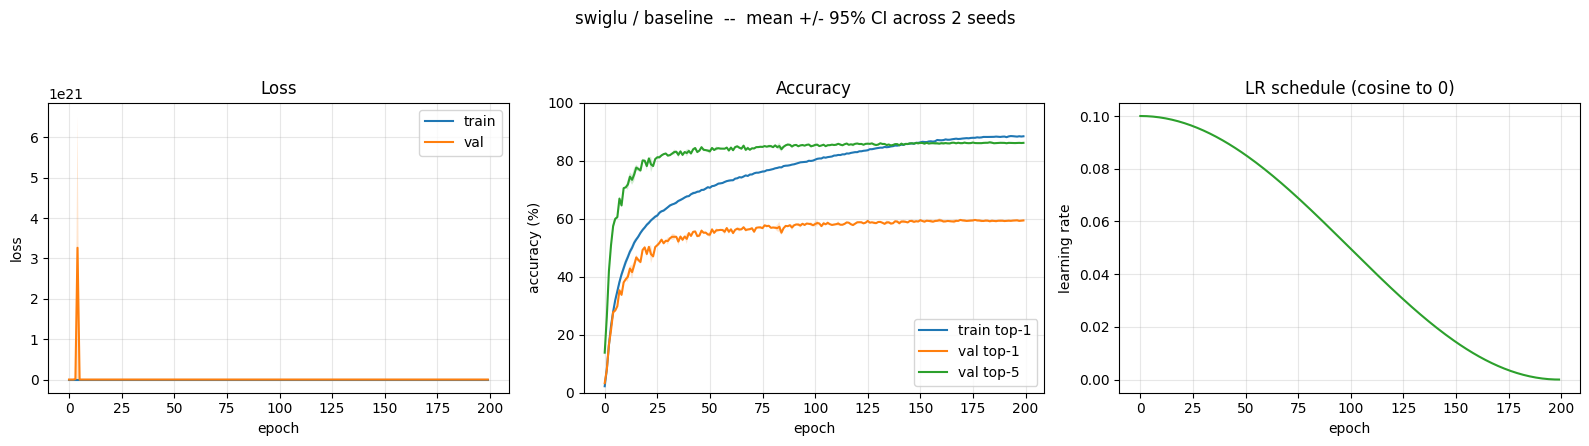

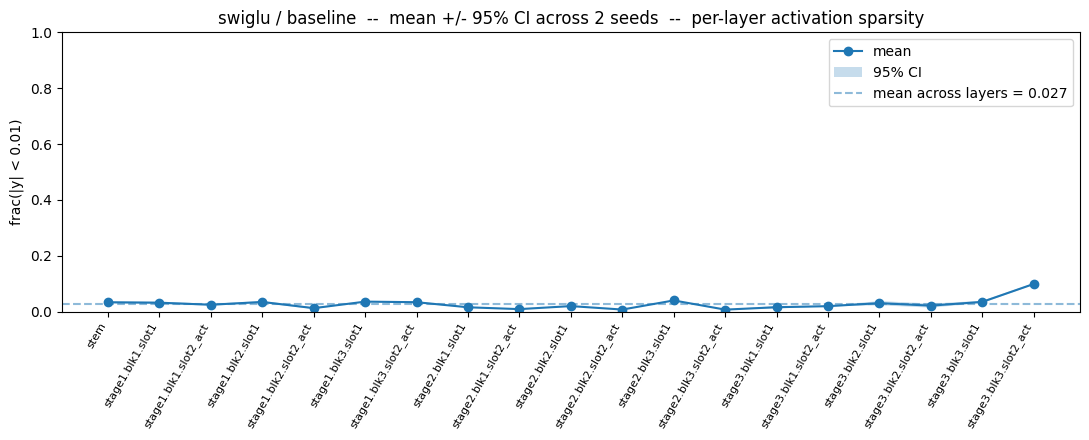

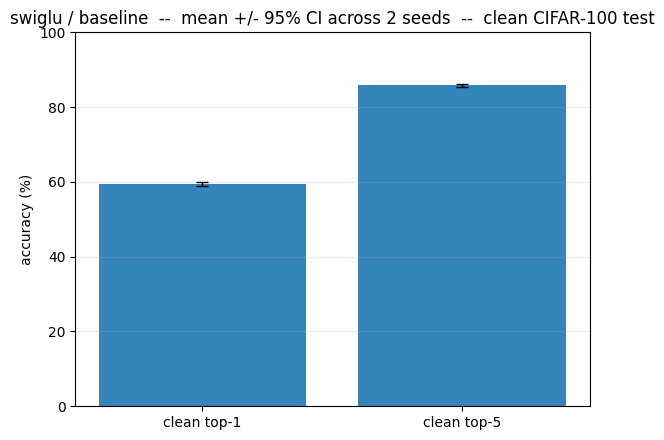


--- Aggregate clean diagnostics: cell=dropout (n=2 seeds) ---


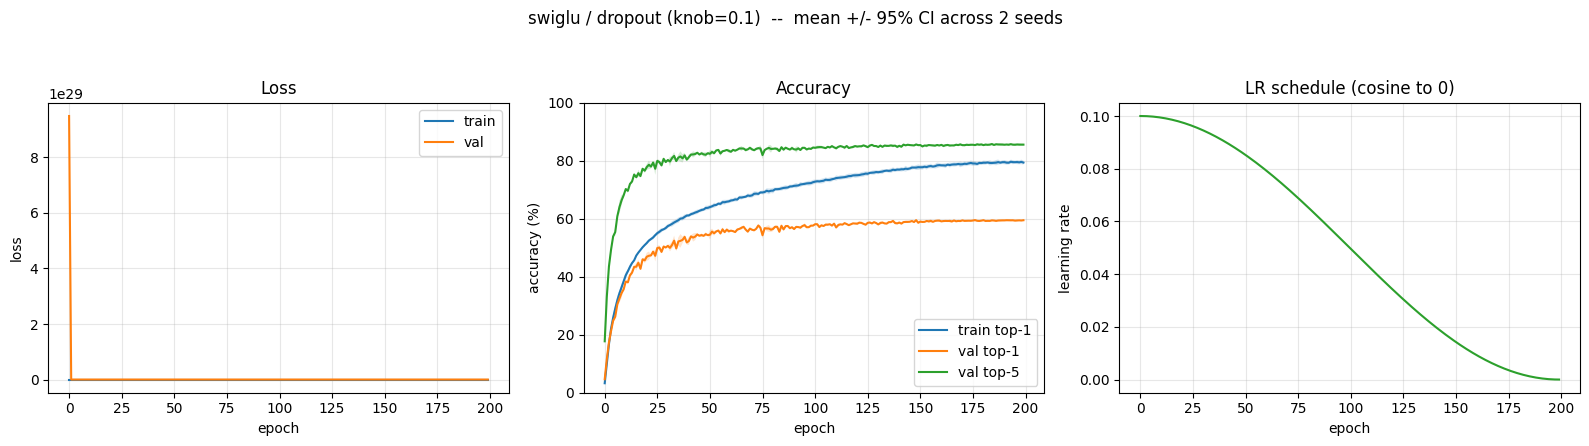

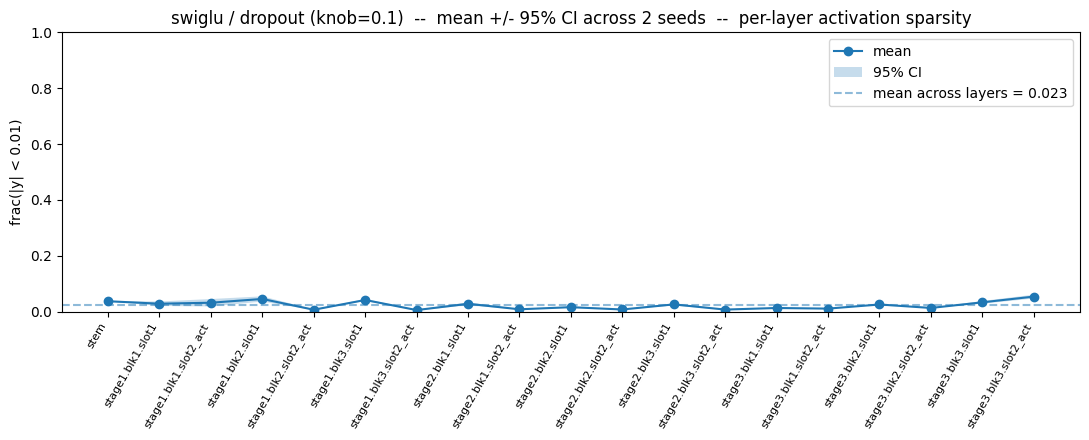

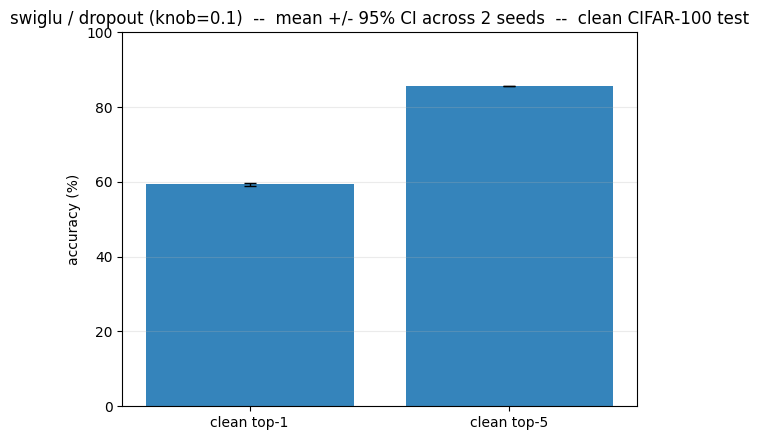


--- Aggregate clean diagnostics: cell=weight_decay (n=2 seeds) ---


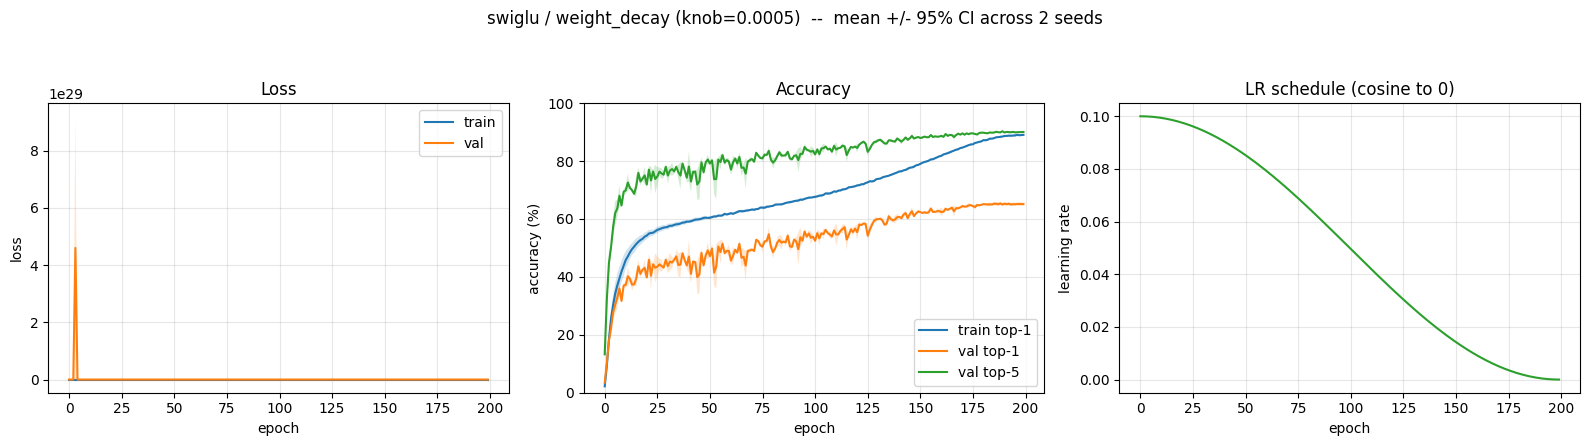

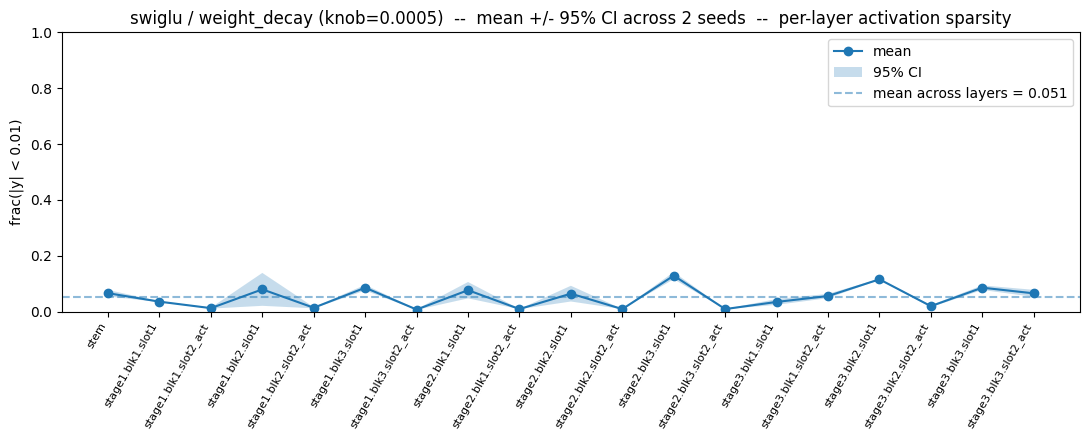

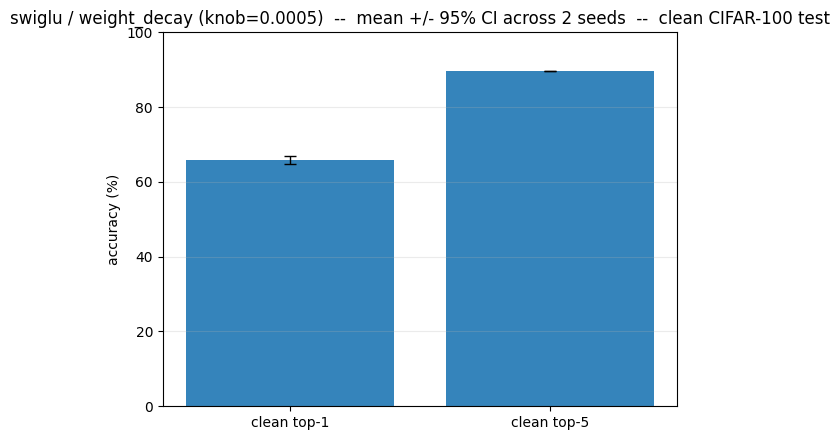


--- Aggregate clean diagnostics: cell=stochastic_depth (n=2 seeds) ---


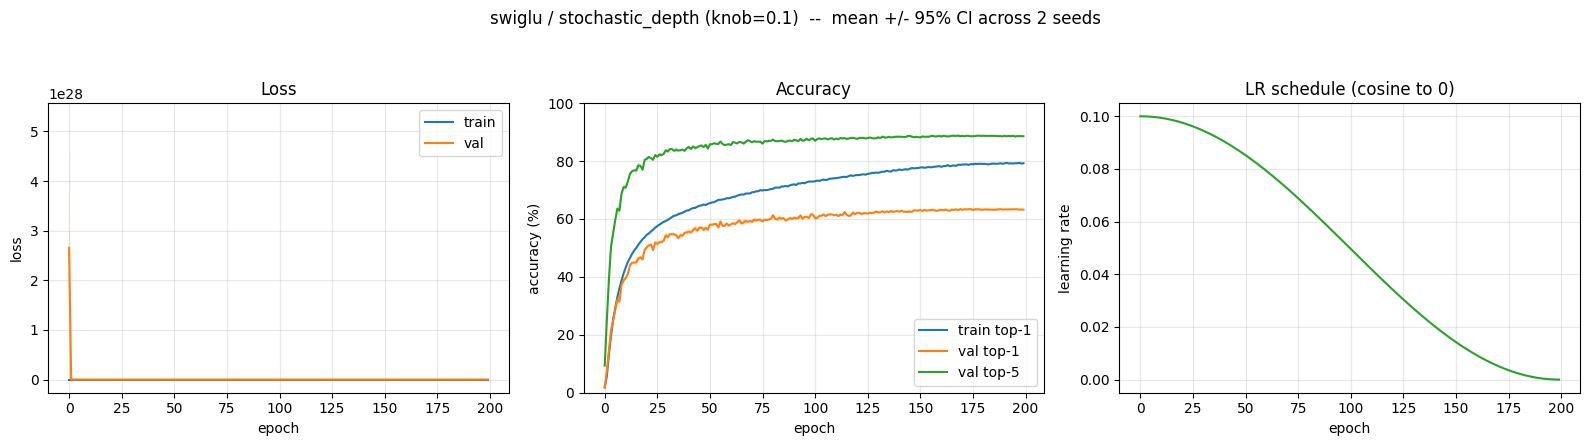

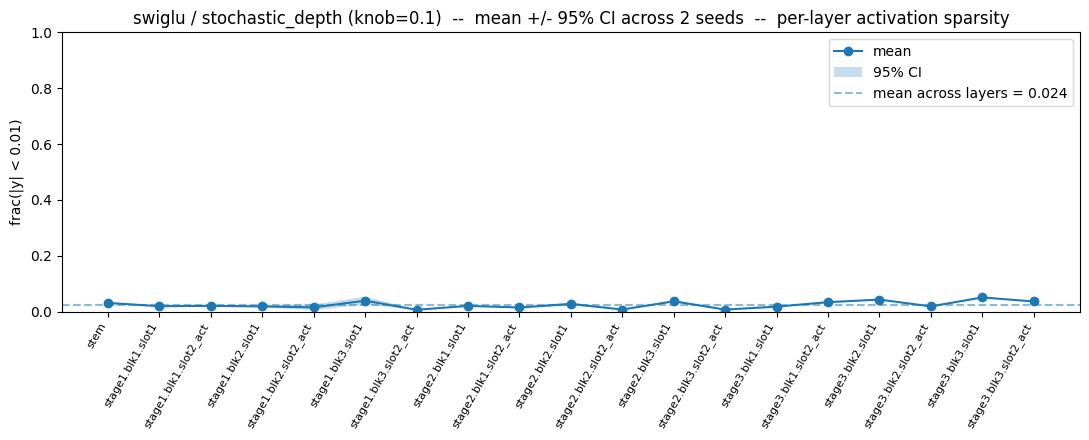

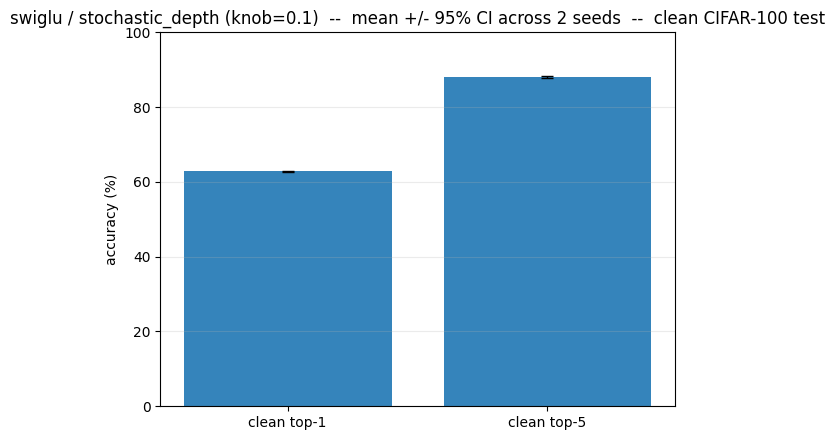

In [20]:
# =====================================================================
# Cell 19 -- Aggregate per-regularizer-cell diagnostics (CI across seeds)
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np


def mean_ci(values, method: str = "bootstrap", conf: float = 0.95,
            n_boot: int = 5000, seed: int = 0):
    """Return (mean, ci_lo, ci_hi). Bootstrap if method='bootstrap', else t-CI."""
    x = np.asarray(list(values), dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return float("nan"), float("nan"), float("nan")
    m = float(np.mean(x))
    if n == 1:
        return m, m, m
    if method == "bootstrap":
        rng = np.random.default_rng(seed)
        boots = np.empty(n_boot, dtype=float)
        for i in range(n_boot):
            boots[i] = float(np.mean(rng.choice(x, size=n, replace=True)))
        lo = float(np.quantile(boots, (1.0 - conf) / 2.0))
        hi = float(np.quantile(boots, 1.0 - (1.0 - conf) / 2.0))
        return m, lo, hi
    # t-interval
    s = float(np.std(x, ddof=1))
    se = s / np.sqrt(n)
    try:
        from scipy import stats as sps
        tcrit = float(sps.t.ppf(0.5 + conf / 2.0, df=n - 1))
    except Exception:
        tcrit = 1.96
    return m, m - tcrit * se, m + tcrit * se


def _ci_per_axis(stack, ci_method: str = "bootstrap", base_seed: int = 0):
    """stack shape (n_seeds, T) -> (mu[T], lo[T], hi[T])."""
    arr = np.asarray(stack, dtype=float)
    if arr.size == 0:
        return np.array([]), np.array([]), np.array([])
    if arr.ndim != 2:
        raise ValueError(f"expected 2D stack, got shape {arr.shape}")
    _, T = arr.shape
    mu = np.zeros(T); lo = np.zeros(T); hi = np.zeros(T)
    for j in range(T):
        m, l, h = mean_ci(arr[:, j], method=ci_method, seed=base_seed + j + 1)
        mu[j], lo[j], hi[j] = m, l, h
    return mu, lo, hi


def plot_aggregate_clean_for_cell(runs_for_cell, ci_method: str = "bootstrap"):
    """Aggregate a list of seeded runs (same regularizer cell) into:
       - training curves with CI ribbons
       - per-layer sparsity with CI ribbon
       - clean CIFAR-100 endpoint bars with CI

    Returns (curves_fig, sparsity_fig, endpoint_fig).
    """
    if not runs_for_cell:
        return None, None, None

    cell_name  = runs_for_cell[0]["cell"]
    activation = runs_for_cell[0]["activation"]
    knob       = runs_for_cell[0]["knob"]
    n          = len(runs_for_cell)

    sup = f"{activation} / {cell_name}"
    if cell_name != "baseline":
        sup += f" (knob={knob})"
    sup += f"  --  mean +/- 95% CI across {n} seeds"

    # --- training curves ---
    min_e  = min(len(r["history"]["epoch"]) for r in runs_for_cell)
    epochs = runs_for_cell[0]["history"]["epoch"][:min_e]
    metric_keys = ["train_loss", "val_loss", "train_top1", "val_top1", "val_top5", "lr"]
    stacks = {}
    for m in metric_keys:
        rows = [r["history"].get(m, [])[:min_e] for r in runs_for_cell]
        rows = [row for row in rows if len(row) == min_e]
        stacks[m] = np.asarray(rows, dtype=float) if rows else np.empty((0, 0))

    curves_fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for m, label in [("train_loss", "train"), ("val_loss", "val")]:
        if stacks[m].size:
            mu, lo, hi = _ci_per_axis(stacks[m], ci_method=ci_method, base_seed=10)
            axes[0].plot(epochs, mu, label=label, linewidth=1.5)
            axes[0].fill_between(epochs, lo, hi, alpha=0.2)
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    for m, label in [("train_top1", "train top-1"),
                     ("val_top1",   "val top-1"),
                     ("val_top5",   "val top-5")]:
        if stacks[m].size:
            mu, lo, hi = _ci_per_axis(stacks[m], ci_method=ci_method, base_seed=20)
            axes[1].plot(epochs, mu * 100, label=label, linewidth=1.5)
            axes[1].fill_between(epochs, lo * 100, hi * 100, alpha=0.2)
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy (%)")
    axes[1].set_ylim(0, 100); axes[1].set_title("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    if stacks["lr"].size:
        axes[2].plot(epochs, stacks["lr"].mean(axis=0), linewidth=1.5, color="C2")
    axes[2].set_xlabel("epoch"); axes[2].set_ylabel("learning rate")
    axes[2].set_title("LR schedule (cosine to 0)"); axes[2].grid(alpha=0.3)

    curves_fig.suptitle(sup)
    curves_fig.tight_layout(rect=[0, 0, 1, 0.93])

    # --- per-layer sparsity ---
    sp0         = runs_for_cell[0]["sparsity"]
    layer_order = sp0["_layer_order"]
    eps         = sp0["_eps"]
    matrix      = np.array([
        [r["sparsity"]["per_layer"][name] for name in layer_order]
        for r in runs_for_cell
    ], dtype=float)
    mu, lo, hi = _ci_per_axis(matrix, ci_method=ci_method, base_seed=30)

    sparsity_fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(layer_order))
    ax.plot(x, mu, marker="o", linewidth=1.5, label="mean")
    ax.fill_between(x, lo, hi, alpha=0.25, label="95% CI")
    headline = float(np.mean(mu))
    ax.axhline(headline, ls="--", alpha=0.5, label=f"mean across layers = {headline:.3f}")
    ax.set_xticks(x)
    ax.set_xticklabels(layer_order, rotation=60, ha="right", fontsize=8)
    ax.set_ylabel(f"frac(|y| < {eps})"); ax.set_ylim(0, 1)
    ax.set_title(f"{sup}  --  per-layer activation sparsity")
    ax.legend(); sparsity_fig.tight_layout()

    # --- clean CIFAR-100 endpoint ---
    top1_vals = np.array([r["test"]["top1"] for r in runs_for_cell], dtype=float)
    top5_vals = np.array([r["test"]["top5"] for r in runs_for_cell], dtype=float)
    m1, l1, h1 = mean_ci(top1_vals, method=ci_method, seed=41)
    m5, l5, h5 = mean_ci(top5_vals, method=ci_method, seed=42)

    endpoint_fig, ax = plt.subplots(figsize=(6, 4.5))
    xs = np.arange(2)
    means = np.array([m1, m5]) * 100
    yerr = np.vstack([
        np.array([m1 - l1, m5 - l5]) * 100,
        np.array([h1 - m1, h5 - m5]) * 100,
    ])
    ax.bar(xs, means, alpha=0.9)
    ax.errorbar(xs, means, yerr=yerr, fmt="none", ecolor="black", capsize=4, linewidth=1)
    ax.set_xticks(xs); ax.set_xticklabels(["clean top-1", "clean top-5"])
    ax.set_ylabel("accuracy (%)"); ax.set_ylim(0, 100)
    ax.set_title(f"{sup}  --  clean CIFAR-100 test")
    ax.grid(axis="y", alpha=0.25)
    endpoint_fig.tight_layout()

    return curves_fig, sparsity_fig, endpoint_fig


# Default: aggregate per regularizer cell from `all_runs`.
if "all_runs" in globals() and len(all_runs) > 0:
    cells_seen = []
    for c, _ in SWEEP_GRID:
        if c not in cells_seen:
            cells_seen.append(c)
    for c in cells_seen:
        runs_c = [r for r in all_runs if r["cell"] == c]
        if not runs_c:
            continue
        print(f"\n--- Aggregate clean diagnostics: cell={c} (n={len(runs_c)} seeds) ---")
        plot_aggregate_clean_for_cell(runs_c)
        plt.show()
else:
    print("No `all_runs` found. Run Cell 17 first.")

## Aggregate CIFAR-100-C analysis per regularizer cell (CI across seeds)

CIFAR-100-C is evaluated inline by **Cell 17** for every (regularizer cell, seed) and stored in each run's `cifar100c` payload. The next cell aggregates those payloads, producing one figure set per regularizer cell:

- **Severity profile** (mean over corruptions per seed, then mean +/- 95% CI across seeds).
- **Per-corruption mean top-1** (mean over severities per seed, then mean +/- 95% CI across seeds), sorted by mean.

### Sampling policy (set in Cell 17)

- Exactly `CIFAR100C_IMAGES_PER_CORR = 10,000` images per corruption (same size as clean CIFAR-100 test set).
- Budget split evenly across severities (default 2,000 per severity x 5 severities).
- Indices are picked with `np.random.default_rng(_corruption_seed(corruption, severity, eval_run_id))`, with `eval_run_id` set to each run's seed -- so seed-0 runs across activations see the **same** images.


--- Aggregate CIFAR-100-C: cell=baseline (n=2 seeds) ---


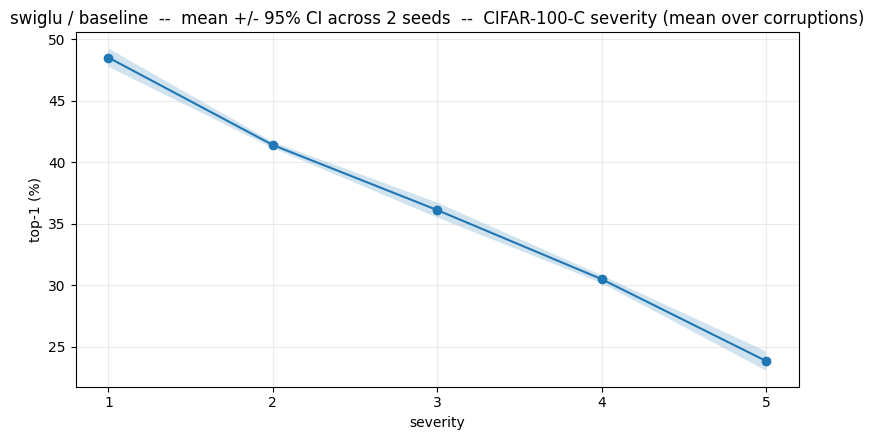

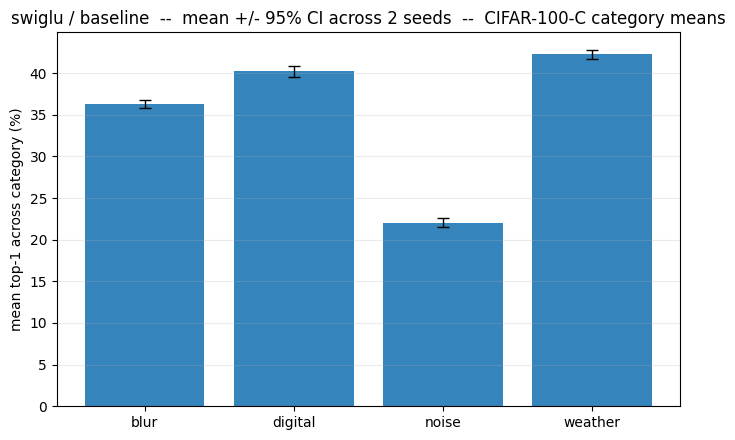

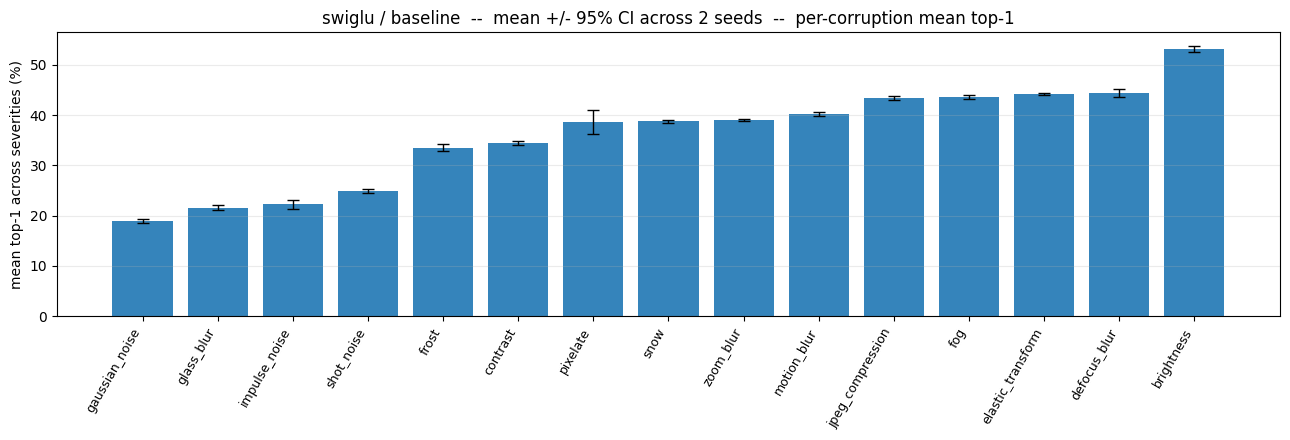


--- Aggregate CIFAR-100-C: cell=dropout (n=2 seeds) ---


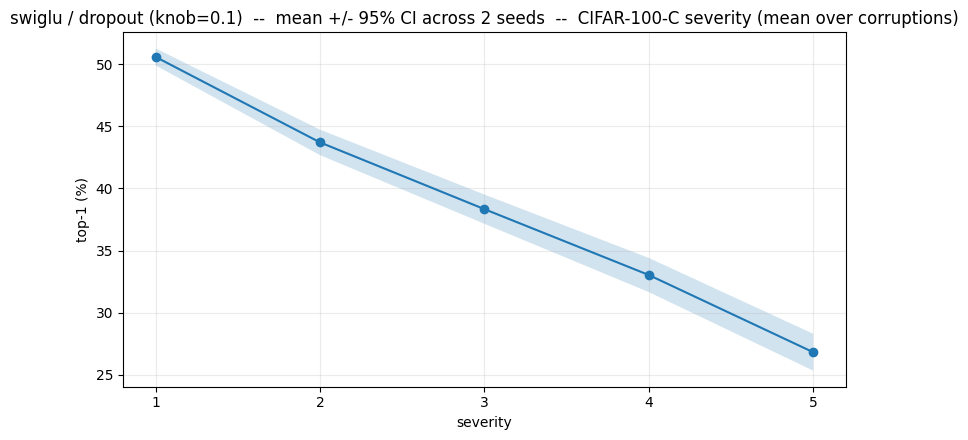

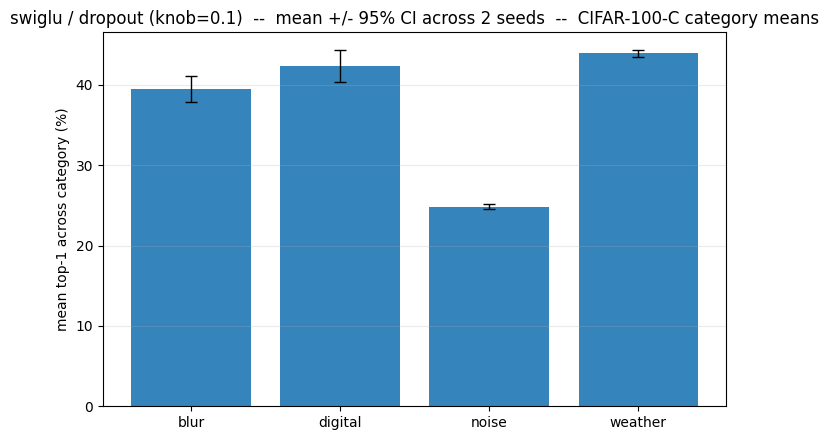

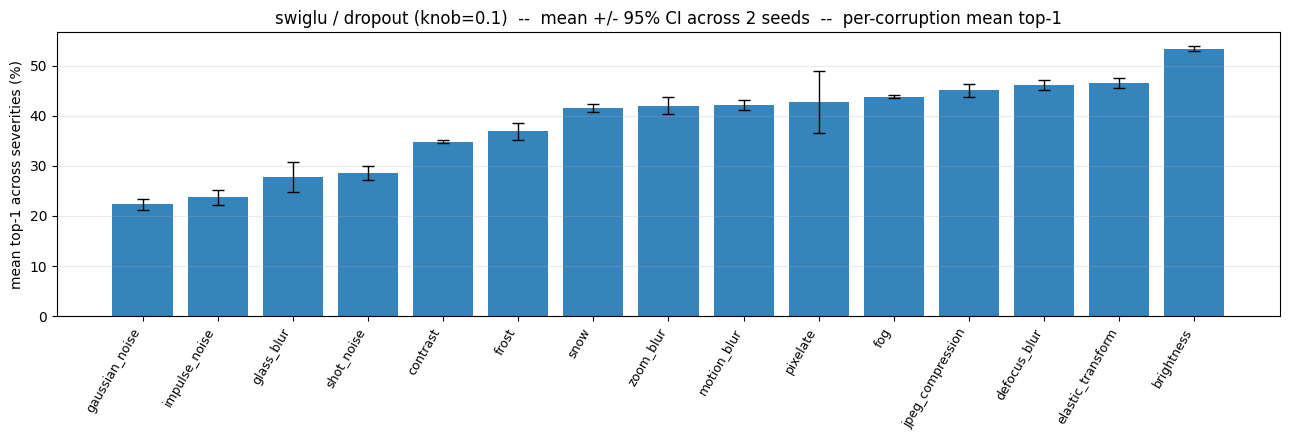


--- Aggregate CIFAR-100-C: cell=weight_decay (n=2 seeds) ---


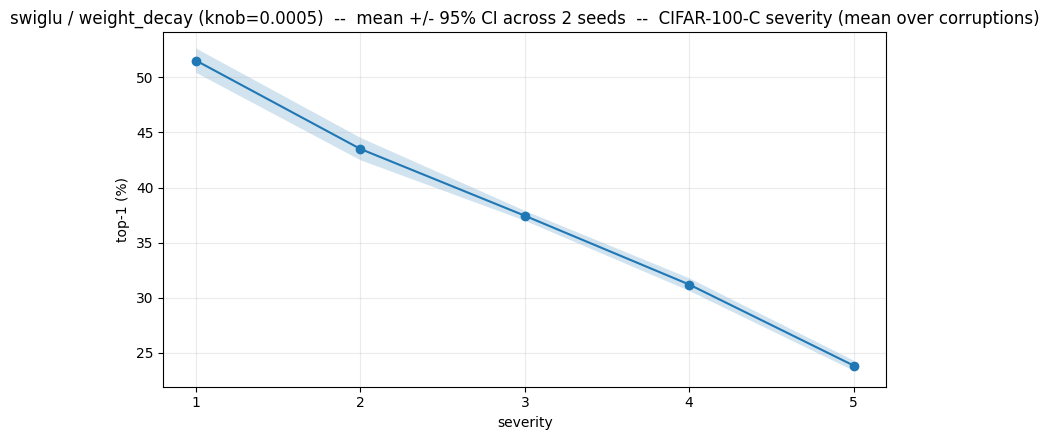

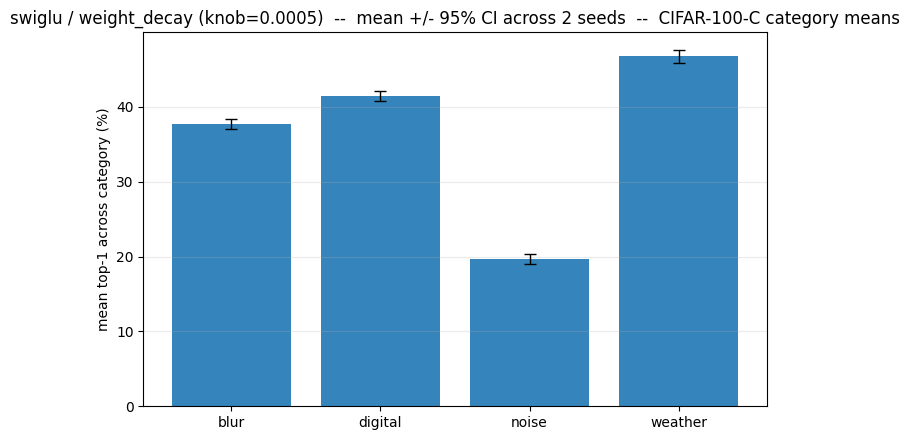

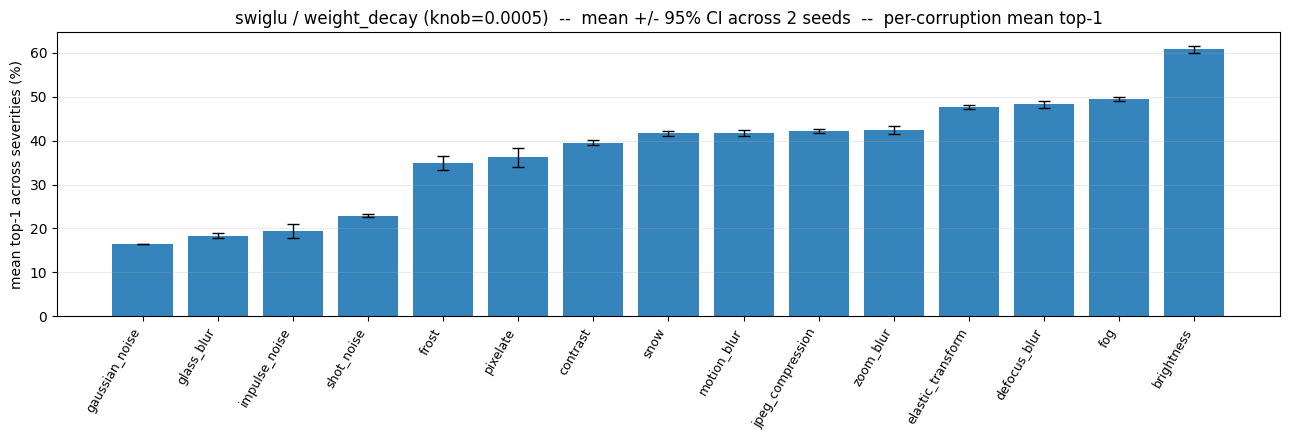


--- Aggregate CIFAR-100-C: cell=stochastic_depth (n=2 seeds) ---


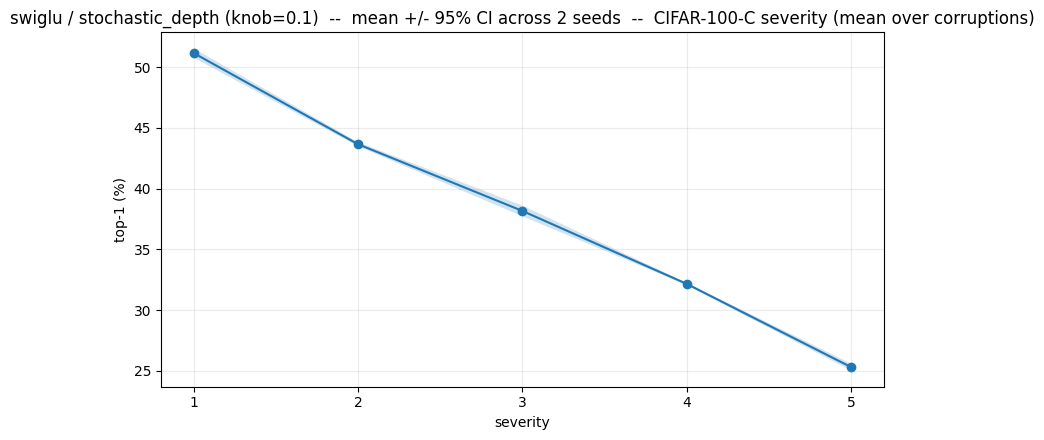

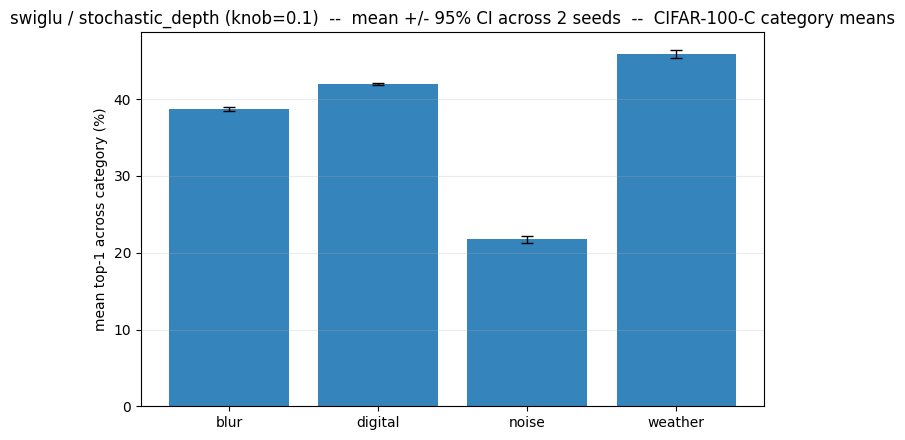

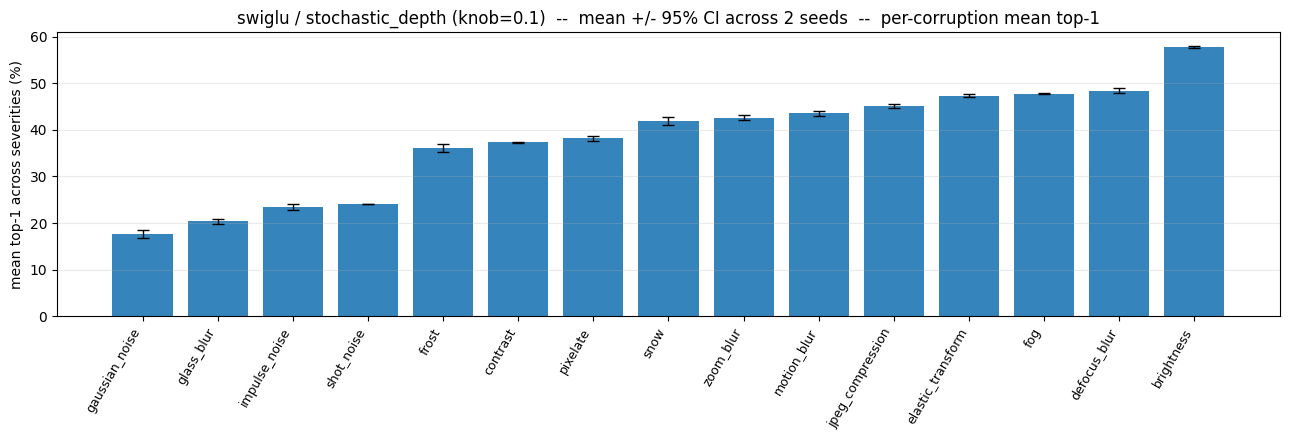

In [21]:
# =====================================================================
# Cell 21 -- Aggregate CIFAR-100-C per regularizer cell (CI across seeds)
# =====================================================================
#
# CIFAR-100-C eval helpers (ensure_cifar100c, evaluate_cifar100c, ...) are
# defined in Cell 17 and run inline during training. Each run dict has a
# `cifar100c` payload. This cell aggregates those payloads per regularizer
# cell and renders one figure set per cell with 95% CI ribbons/bars across
# the seeded runs (no ANOVA).

import matplotlib.pyplot as plt
import numpy as np

# `mean_ci` is defined in Cell 19; provide a fallback so this cell works even
# if Cell 19 hasn't been run yet (e.g., a user only re-runs Cell 21).
if "mean_ci" not in globals():
    def mean_ci(values, method: str = "bootstrap", conf: float = 0.95,
                n_boot: int = 5000, seed: int = 0):
        x = np.asarray(list(values), dtype=float)
        x = x[np.isfinite(x)]
        n = x.size
        if n == 0:
            return float("nan"), float("nan"), float("nan")
        m = float(np.mean(x))
        if n == 1:
            return m, m, m
        rng = np.random.default_rng(seed)
        boots = np.empty(n_boot, dtype=float)
        for i in range(n_boot):
            boots[i] = float(np.mean(rng.choice(x, size=n, replace=True)))
        return (m,
                float(np.quantile(boots, (1.0 - conf) / 2.0)),
                float(np.quantile(boots, 1.0 - (1.0 - conf) / 2.0)))


def plot_aggregate_c100c_for_cell(runs_for_cell, ci_method: str = "bootstrap"):
    """Aggregate CIFAR-100-C plots for one regularizer cell.

    Returns:
        (severity_fig, category_fig, per_corruption_fig)
    """
    if not runs_for_cell:
        return None, None, None

    activation = runs_for_cell[0]["activation"]
    cell_name  = runs_for_cell[0]["cell"]
    knob       = runs_for_cell[0]["knob"]
    n          = len(runs_for_cell)

    sup = f"{activation} / {cell_name}"
    if cell_name != "baseline":
        sup += f" (knob={knob})"
    sup += f"  --  mean +/- 95% CI across {n} seeds"

    # Build (seed_idx, corruption, severity) -> top1 grid.
    sev_set = set()
    corr_set = set()
    grid = {}
    for i, r in enumerate(runs_for_cell):
        per = r.get("cifar100c", {}).get("per_corruption", {})
        for corr, sev_map in per.items():
            corr_set.add(corr)
            for sev, m in sev_map.items():
                sev_set.add(int(sev))
                grid[(i, corr, int(sev))] = float(m["top1"])

    sevs  = sorted(sev_set)
    corrs = sorted(corr_set)
    if not corrs or not sevs:
        return None, None, None

    # ---------- severity profile (mean over corruptions per seed) ----------
    seed_sev_means = np.full((n, len(sevs)), np.nan)
    for i in range(n):
        for j, s in enumerate(sevs):
            vals = [grid.get((i, c, s), np.nan) for c in corrs]
            vals = [v for v in vals if np.isfinite(v)]
            if vals:
                seed_sev_means[i, j] = float(np.mean(vals))

    sev_fig, ax = plt.subplots(figsize=(8, 4.5))
    mu, lo, hi = [], [], []
    for j, s in enumerate(sevs):
        m, l, h = mean_ci(seed_sev_means[:, j], method=ci_method, seed=200 + s)
        mu.append(m); lo.append(l); hi.append(h)
    mu = np.array(mu); lo = np.array(lo); hi = np.array(hi)
    ax.plot(sevs, mu * 100, marker="o", linewidth=1.5)
    ax.fill_between(sevs, lo * 100, hi * 100, alpha=0.2)
    ax.set_xticks(sevs); ax.set_xlabel("severity"); ax.set_ylabel("top-1 (%)")
    ax.grid(alpha=0.25)
    ax.set_title(f"{sup}  --  CIFAR-100-C severity (mean over corruptions)")
    sev_fig.tight_layout()

    # ---------- per-category bars (mean over corruptions in category) ----------
    cats_present = sorted({CIFAR100C_CATEGORY.get(c, "other") for c in corrs})
    cat_means = {cat: np.full(n, np.nan) for cat in cats_present}
    for i in range(n):
        for cat in cats_present:
            cat_corr = [c for c in corrs if CIFAR100C_CATEGORY.get(c, "other") == cat]
            vals = []
            for c in cat_corr:
                cv = [grid.get((i, c, s), np.nan) for s in sevs]
                cv = [v for v in cv if np.isfinite(v)]
                if cv:
                    vals.append(float(np.mean(cv)))
            if vals:
                cat_means[cat][i] = float(np.mean(vals))

    cat_fig, ax = plt.subplots(figsize=(7, 4.5))
    means = []; los = []; his = []
    for k, cat in enumerate(cats_present):
        m, l, h = mean_ci(cat_means[cat], method=ci_method, seed=400 + k)
        means.append(m); los.append(l); his.append(h)
    means = np.array(means); los = np.array(los); his = np.array(his)
    xs = np.arange(len(cats_present))
    yerr = np.vstack([(means - los) * 100, (his - means) * 100])
    ax.bar(xs, means * 100, alpha=0.9)
    ax.errorbar(xs, means * 100, yerr=yerr, fmt="none", ecolor="black", capsize=4, linewidth=1)
    ax.set_xticks(xs); ax.set_xticklabels(cats_present)
    ax.set_ylabel("mean top-1 across category (%)")
    ax.set_title(f"{sup}  --  CIFAR-100-C category means")
    ax.grid(axis="y", alpha=0.25)
    cat_fig.tight_layout()

    # ---------- per-corruption mean top-1 with CI bars ----------
    seed_corr_means = np.full((n, len(corrs)), np.nan)
    for i in range(n):
        for k, c in enumerate(corrs):
            vals = [grid.get((i, c, s), np.nan) for s in sevs]
            vals = [v for v in vals if np.isfinite(v)]
            if vals:
                seed_corr_means[i, k] = float(np.mean(vals))

    means = []; los = []; his = []
    for k in range(len(corrs)):
        m, l, h = mean_ci(seed_corr_means[:, k], method=ci_method, seed=300 + k)
        means.append(m); los.append(l); his.append(h)
    order = np.argsort(means)
    corrs_sorted = [corrs[i] for i in order]
    means_sorted = np.array(means)[order]
    los_sorted   = np.array(los)[order]
    his_sorted   = np.array(his)[order]

    pc_fig, ax = plt.subplots(figsize=(13, 4.5))
    xs = np.arange(len(corrs_sorted))
    yerr = np.vstack([(means_sorted - los_sorted) * 100,
                      (his_sorted   - means_sorted) * 100])
    ax.bar(xs, means_sorted * 100, alpha=0.9)
    ax.errorbar(xs, means_sorted * 100, yerr=yerr, fmt="none", ecolor="black", capsize=4, linewidth=1)
    ax.set_xticks(xs); ax.set_xticklabels(corrs_sorted, rotation=60, ha="right", fontsize=9)
    ax.set_ylabel("mean top-1 across severities (%)")
    ax.set_title(f"{sup}  --  per-corruption mean top-1")
    ax.grid(axis="y", alpha=0.25)
    pc_fig.tight_layout()

    return sev_fig, cat_fig, pc_fig


# Default: aggregate per regularizer cell from `all_runs`.
if "all_runs" in globals() and len(all_runs) > 0:
    cells_seen = []
    for c, _ in SWEEP_GRID:
        if c not in cells_seen:
            cells_seen.append(c)
    for c in cells_seen:
        runs_c = [r for r in all_runs if r["cell"] == c and "cifar100c" in r]
        if not runs_c:
            continue
        print(f"\n--- Aggregate CIFAR-100-C: cell={c} (n={len(runs_c)} seeds) ---")
        plot_aggregate_c100c_for_cell(runs_c)
        plt.show()
else:
    print("No `all_runs` with CIFAR-100-C data found. Run Cell 17 first.")

## Cross-regularizer summary (CI only, no ANOVA)

The next cell consumes `all_runs` (every regularizer cell x every seed for the chosen activation) and produces a side-by-side comparison of regularizer cells with **mean +/- 95% CI** across seeds:

- Clean CIFAR-100 top-1 and top-5
- CIFAR-100-C mean top-1 (averaged over corruptions and severities)
- Mean per-layer activation sparsity (the headline metric)

ANOVA is intentionally omitted here -- the per-cell aggregate plots in Cells 19 and 21 already carry CI across seeds for each regularizer combination, which is what we want for now.


Cross-regularizer summary (mean +/- 95% CI across seeds):
                         hi                                           lo  \
metric           c100c_top1 sparsity_mean test_top1 test_top5 c100c_top1   
cell                                                                       
baseline             0.3661        0.0275    0.5989    0.8618     0.3553   
dropout              0.3964        0.0235    0.5969    0.8571     0.3735   
stochastic_depth     0.3837        0.0246    0.6304    0.8842     0.3782   
weight_decay         0.3822        0.0560    0.6686    0.8972     0.3678   

                                                         mean                \
metric           sparsity_mean test_top1 test_top5 c100c_top1 sparsity_mean   
cell                                                                          
baseline                0.0274    0.5900    0.8550     0.3607        0.0274   
dropout                 0.0223    0.5904    0.8557     0.3850        0.0229   
stochastic_de

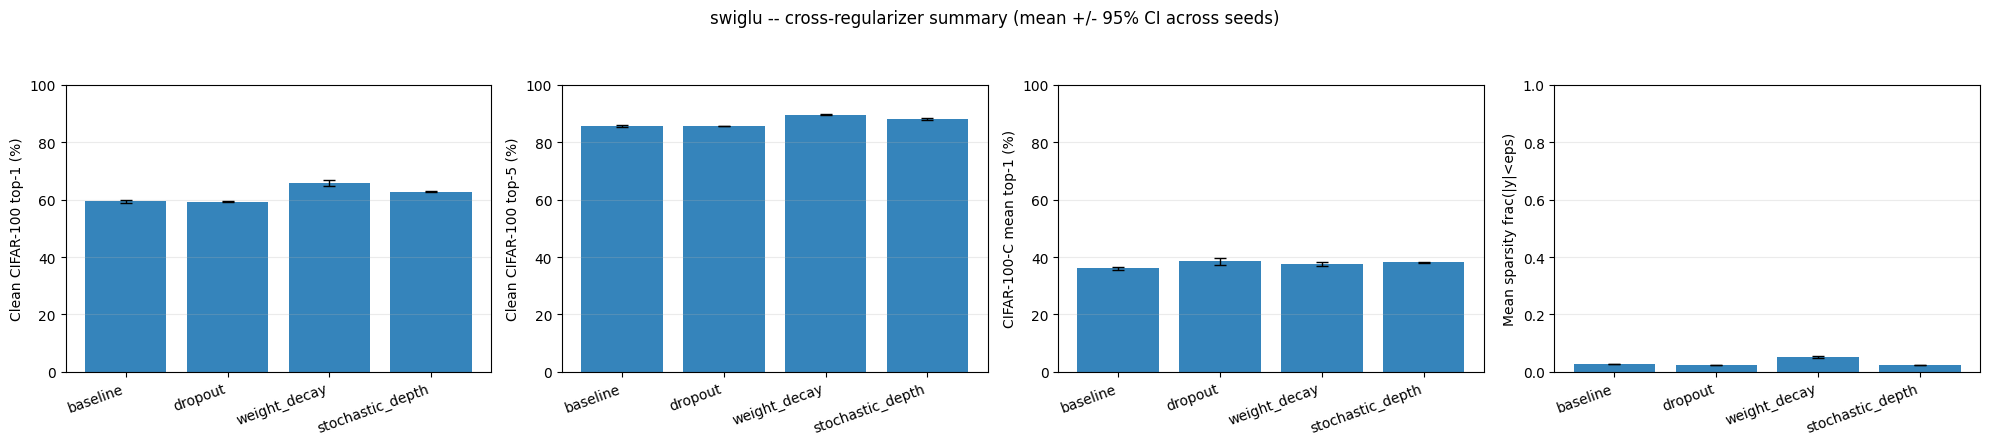

In [22]:
# =====================================================================
# Cell 23 -- Cross-regularizer-cell summary (CI only, no ANOVA)
# =====================================================================
#
# Compares regularizer cells (baseline / dropout / weight_decay /
# stochastic_depth) side-by-side for the chosen activation, using
# mean +/- 95% CI across seeded runs in `all_runs`.
#
# Removed in this revision: ANOVA, statsmodels dependence, and the
# per-activation comparison utilities. The aggregate-per-cell plots in
# Cells 19 and 21 already report CI across seeds for each regularizer
# combination, which is the intended analysis for now.
# =====================================================================

import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Reuse `mean_ci` if defined upstream (Cell 19); otherwise provide a fallback.
if "mean_ci" not in globals():
    def mean_ci(values, method: str = "bootstrap", conf: float = 0.95,
                n_boot: int = 5000, seed: int = 0):
        x = np.asarray(list(values), dtype=float)
        x = x[np.isfinite(x)]
        n = x.size
        if n == 0:
            return float("nan"), float("nan"), float("nan")
        m = float(np.mean(x))
        if n == 1:
            return m, m, m
        rng = np.random.default_rng(seed)
        boots = np.empty(n_boot, dtype=float)
        for i in range(n_boot):
            boots[i] = float(np.mean(rng.choice(x, size=n, replace=True)))
        return (m,
                float(np.quantile(boots, (1.0 - conf) / 2.0)),
                float(np.quantile(boots, 1.0 - (1.0 - conf) / 2.0)))


def runs_summary_table(runs):
    """One row per run with the headline metrics needed for the summary plot."""
    rows = []
    for r in runs:
        c100c = r.get("cifar100c", {}) or {}
        rows.append({
            "activation":    r.get("activation"),
            "cell":          r.get("cell"),
            "knob":          r.get("knob"),
            "seed":          r.get("seed"),
            "test_top1":     float(r.get("test", {}).get("top1", float("nan"))),
            "test_top5":     float(r.get("test", {}).get("top5", float("nan"))),
            "c100c_top1":    float(c100c.get("mean_top1", float("nan"))),
            "sparsity_mean": float(r.get("sparsity", {}).get("headline_mean", float("nan"))),
        })
    return pd.DataFrame(rows)


def plot_cross_cell_summary(runs, ci_method: str = "bootstrap"):
    """Bars per regularizer cell with mean +/- 95% CI across seeds.

    Renders one figure with subplots for clean top-1, clean top-5,
    CIFAR-100-C mean top-1, and mean activation sparsity.
    """
    df = runs_summary_table(runs)
    if df.empty:
        print("No runs to summarize.")
        return None

    activation = df["activation"].iloc[0]
    cells_in_order = [c for c, _ in SWEEP_GRID if c in df["cell"].unique()]

    metrics = [
        ("test_top1",     "Clean CIFAR-100 top-1 (%)",   100.0, (0, 100)),
        ("test_top5",     "Clean CIFAR-100 top-5 (%)",   100.0, (0, 100)),
        ("c100c_top1",    "CIFAR-100-C mean top-1 (%)",  100.0, (0, 100)),
        ("sparsity_mean", "Mean sparsity frac(|y|<eps)",   1.0, (0,   1)),
    ]

    fig, axes = plt.subplots(1, len(metrics), figsize=(5.0 * len(metrics), 4.5))
    summary_rows = []
    for ax, (col, ylabel, scale, ylim) in zip(axes, metrics):
        labels, means, los, his = [], [], [], []
        for c in cells_in_order:
            sub = df[df["cell"] == c][col].dropna().values
            if len(sub) == 0:
                continue
            m, lo, hi = mean_ci(sub, method=ci_method, seed=hash((c, col)) % 9_999)
            labels.append(c); means.append(m); los.append(lo); his.append(hi)
            summary_rows.append({"cell": c, "metric": col,
                                 "mean": m, "lo": lo, "hi": hi, "n": int(len(sub))})
        means = np.array(means); los = np.array(los); his = np.array(his)
        x = np.arange(len(labels))
        y = means * scale
        yerr = np.vstack([(means - los) * scale, (his - means) * scale])
        ax.bar(x, y, alpha=0.9)
        ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="black", capsize=4, linewidth=1)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylabel(ylabel); ax.grid(axis="y", alpha=0.25)
        ax.set_ylim(*ylim)

    fig.suptitle(f"{activation} -- cross-regularizer summary "
                 f"(mean +/- 95% CI across seeds)")
    fig.tight_layout(rect=[0, 0, 1, 0.93])

    sdf = pd.DataFrame(summary_rows)
    if not sdf.empty:
        print("\nCross-regularizer summary (mean +/- 95% CI across seeds):")
        with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
            print(sdf.pivot_table(index="cell", columns="metric",
                                  values=["mean", "lo", "hi", "n"]))
    return fig


def load_runs_from_json(pattern: str = "./results_*/*.json"):
    """Reload run dicts saved by Cell 17 across one or more result directories."""
    runs = []
    for path in sorted(glob.glob(pattern)):
        with open(path, "r") as f:
            runs.append(json.load(f))
    return runs


# Default behavior: cross-regularizer summary on `all_runs` from Cell 17.
if "all_runs" in globals() and len(all_runs) > 0:
    plot_cross_cell_summary(all_runs)
    plt.show()
else:
    print("No `all_runs` found. Run Cell 17 first, "
          "or use load_runs_from_json(...) to reload from disk.")
